In [1]:
# ══════════════════════════════════════════════════════════════════
#  ANTI-DESCONEXION COLAB
#  Simula actividad cada 2 min para evitar timeout por inactividad.
# ══════════════════════════════════════════════════════════════════

try:
    import google.colab
    ENTORNO = 'colab'
except ImportError:
    ENTORNO = 'local'

if ENTORNO == 'colab':
    import IPython
    IPython.display.display(IPython.display.Javascript('''
        function keepAlive() {
            var sels = ["colab-connect-button",
                        "#top-toolbar > colab-connect-button",
                        "#connect"];
            for (var i = 0; i < sels.length; i++) {
                var btn = document.querySelector(sels[i]);
                if (btn) { btn.click(); break; }
            }
            console.log("Keep-alive ping: " + new Date().toLocaleTimeString());
        }
        setInterval(keepAlive, 120000);
        console.log("[OK] Anti-desconexion activo — ping cada 2 min.");
    '''))
    print('Anti-desconexion Colab activado (keep-alive cada 2 min).')
    print('Tip: NO minimices la pestana del navegador para evitar throttling de JS.')
else:
    print('Entorno local — anti-desconexion no necesario.')

<IPython.core.display.Javascript object>

Anti-desconexion Colab activado (keep-alive cada 2 min).
Tip: NO minimices la pestana del navegador para evitar throttling de JS.


═══════════════════════════════════════════════════════════════════════

BLOQUE 1 — DEPENDENCIAS
═══════════════════════════════════════════════════════════════════════


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 1 — Dependencias (VERSIÓN PRO ESTABLE FINAL CORREGIDA)
# ═══════════════════════════════════════════════════════════════════════

import sys
import subprocess
import os
import json
import time
import gc
import warnings
!pip install fastdtw


# ──────────────────────────────────────────────────────────────────────
# Instalador seguro
# ──────────────────────────────────────────────────────────────────────
def _instalar_si_falta(paquete, modulo=None):
    if modulo is None:
        modulo = paquete

    try:
        __import__(modulo)
        return False
    except ImportError:
        print(f'Instalando {paquete}...')
        subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '-q', paquete],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        return True


# ──────────────────────────────────────────────────────────────────────
# Instalaciones
# ──────────────────────────────────────────────────────────────────────
_instalar_si_falta('wfdb')
_instalar_si_falta('psutil')

# DTW opcional
try:
    _instalar_si_falta('dtaidistance')
    import dtaidistance
    DTW_AVAILABLE = True
except Exception:
    DTW_AVAILABLE = False


# ──────────────────────────────────────────────────────────────────────
# Imports principales
# ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import psutil
import wfdb

from scipy import signal as spsig

from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks


# ──────────────────────────────────────────────────────────────────────
# Configuración global
# ──────────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

sns.set_style('whitegrid')

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.titlesize': 12
})


# ──────────────────────────────────────────────────────────────────────
# Seeds (REPRODUCIBILIDAD REAL)
# ──────────────────────────────────────────────────────────────────────
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

rng = np.random.default_rng(SEED)


# ──────────────────────────────────────────────────────────────────────
# GPU CONFIG (ESTABLE Y SEGURA)
# ──────────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.set_logical_device_configuration(
                gpu,
                [tf.config.LogicalDeviceConfiguration(memory_limit=None)]
            )
        print(f'✓ GPU detectada: {gpus[0].name}')
    except Exception as e:
        print('Error configurando GPU:', e)
else:
    print('✓ Ejecutando en CPU')


# ──────────────────────────────────────────────────────────────────────
# INFO SISTEMA
# ──────────────────────────────────────────────────────────────────────
print(f'RAM disponible: {psutil.virtual_memory().available / 1e9:.2f} GB')
print('TensorFlow:', tf.__version__)
print('DTW disponible:', DTW_AVAILABLE)
print('=' * 70)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567858 sha256=445ade892426e028f3344513c2a820254051c587b3848e733b91c521a51cf467
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw
Instalando wfdb...
Instalando dtaidistance...
Error configurando GPU: Setting memory limit is required for GPU virtual devices
RAM disponible: 11.39 GB
TensorFlow: 2.20.0
DTW disponible: True


═══════════════════════════════════════════════════════════════════════

BLOQUE 2 — CONFIGURACIÓN + RUTAS (OPTIMIZADO + LISTO PARA INCART)
═══════════════════════════════════════════════════════════════════════


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 2 — Configuración (FINAL CORREGIDO Y ESTABLE)
# ═══════════════════════════════════════════════════════════════════════

import os

# ──────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN GENERAL
# ──────────────────────────────────────────────────────────────────────

# Señal ECG
FS = 360
NYQUIST = FS / 2

F_BAJO = 0.5
F_ALTO = 40.0
ORDEN_BUT = 4

FREC_NOTCH = 60.0
Q_NOTCH = 30.0

# Segmentación
BEAT_LEN = 256
N_LOOKBACK = 5
HORIZON = 3

BEAT_TYPES = set('NLRBVAFaJfEjeSe/')

# Features
INCLUDE_RR = True
FEAT_DIM = BEAT_LEN + (1 if INCLUDE_RR else 0)

# Dataset
MAX_PARES_POR_PACIENTE = 400

# Data augmentation
AUG_FACTOR = 0.3

# Entrenamiento (Forecasting)
EPOCHS_BASE = 30
PAT_ES_BASE = 15
BATCH_BASE = 32

LR_BASE = 1e-3
DROPOUT_BASE = 0.3

# Fine-tuning
FINE_TUNE_K = 30
FINE_TUNE_EPOCHS = 5
FINE_TUNE_LR = 1e-4

# Anomalia / Calibracion
THRESHOLD_ANOMALY_Z = 3.0
FT_CALIBRATION_BEATS = 30



# 🔹 FIX IMPORTANTE: lista (NO set)
VARIANTES_BASE = ['CNN_GRU_ATTN']

# ──────────────────────────────────────────────────────────────────────
# PACIENTES MIT-BIH
# ──────────────────────────────────────────────────────────────────────
MITBIH_PACIENTES = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119',
    '121','122','123','124',
    '200','201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221','222',
    '223','228','230','231','232','233','234',
]

# ──────────────────────────────────────────────────────────────────────
# PACIENTES INCART
# ──────────────────────────────────────────────────────────────────────
INCART_PACIENTES = [
    f'I{str(i).zfill(2)}' for i in range(1, 76)
]

USAR_INCART = True

TODOS_LOS_PACIENTES = MITBIH_PACIENTES + (
    INCART_PACIENTES if USAR_INCART else []
)

# ──────────────────────────────────────────────────────────────────────
# CONFIGURAR RUTAS
# ──────────────────────────────────────────────────────────────────────
def configurar_rutas():

    try:
        import google.colab
        from google.colab import drive

        drive.mount('/content/drive', force_remount=False)

        base = '/content/drive/MyDrive/FORECASTING ECG'
        os.makedirs(base, exist_ok=True)

        entorno = 'colab'

    except ImportError:
        entorno = 'local'
        base = os.getcwd()

    rutas = {
        'ENTORNO': entorno,
        'BASE': base,

        'DATOS_MITBIH': os.path.join(base, 'datos', 'mit-bih'),
        'DATOS_INCART': os.path.join(base, 'datos', 'incart'),

        'RESULTS': os.path.join(base, 'results', 'NB6'),
        'VIS': os.path.join(base, 'results', 'NB6', 'visualizaciones'),
        'MODELOS': os.path.join(base, 'results', 'NB6', 'modelos'),

        'CHECKPOINT': os.path.join(base, 'results', 'NB6', 'lopo_checkpoint.csv'),
        'CSV_FINAL': os.path.join(base, 'results', 'NB6', 'resultados_lopo.csv'),
        'CSV_RESUMEN': os.path.join(base, 'results', 'NB6', 'tabla_resumen.csv'),
    }

    for k in ['DATOS_MITBIH', 'DATOS_INCART', 'RESULTS', 'VIS', 'MODELOS']:
        os.makedirs(rutas[k], exist_ok=True)

    return rutas


R = configurar_rutas()

# ──────────────────────────────────────────────────────────────────────
# UTILIDAD DISPLAY
# ──────────────────────────────────────────────────────────────────────
def mostrar_tabla(df, titulo=''):
    if titulo:
        print('\n>>', titulo)
    try:
        from IPython.display import display
        display(df.style.background_gradient(cmap='Blues').format(precision=4))
    except Exception:
        print(df.to_string(index=False))

# ──────────────────────────────────────────────────────────────────────
# INFO GENERAL
# ──────────────────────────────────────────────────────────────────────
print('=' * 70)
print(' NB5 — Multi-Step ECG Forecasting')
print('=' * 70)

print(' Entorno :', R['ENTORNO'])
print(' Base    :', R['BASE'])
print(' Pacientes totales:', len(TODOS_LOS_PACIENTES))

print(f' Input   : {N_LOOKBACK} latidos → {HORIZON} futuros')
print(' FeatDim :', FEAT_DIM)
print(' INCART  :', 'ACTIVO' if USAR_INCART else 'NO')

print('=' * 70)

Mounted at /content/drive
 NB5 — Multi-Step ECG Forecasting
 Entorno : colab
 Base    : /content/drive/MyDrive/FORECASTING ECG
 Pacientes totales: 123
 Input   : 5 latidos → 3 futuros
 FeatDim : 257
 INCART  : ACTIVO


═══════════════════════════════════════════════════════════════════════

BLOQUE 3 — CARGA + FILTRADO + R-PEAKS (MULTI-DATASET)
═══════════════════════════════════════════════════════════════════════



 Cargando datasets (optimizado)...
→ 100 ✓ (3.0s)
→ 101 ✓ (2.0s)
→ 102 ✓ (2.0s)
→ 103 ✓ (2.6s)
→ 104 ✓ (1.6s)
→ 105 ✓ (2.2s)
→ 106 ✓ (2.2s)
→ 107 ✓ (1.8s)
→ 108 ✓ (2.1s)
→ 109 ✓ (1.7s)
→ 111 ✓ (1.8s)
→ 112 ✓ (1.8s)
→ 113 ✓ (2.4s)
→ 114 ✓ (1.8s)
→ 115 ✓ (1.8s)
→ 116 ✓ (1.5s)
→ 117 ✓ (1.7s)
→ 118 ✓ (1.4s)
→ 119 ✓ (1.5s)
→ 121 ✓ (1.7s)
→ 122 ✓ (1.8s)
→ 123 ✓ (1.6s)
→ 124 ✓ (1.5s)
→ 200 ✓ (1.8s)
→ 201 ✓ (1.4s)
→ 202 ✓ (1.3s)
→ 203 ✓ (1.5s)
→ 205 ✓ (1.3s)
→ 207 ✓ (1.9s)
→ 208 ✓ (1.7s)
→ 209 ✓ (1.3s)
→ 210 ✓ (2.1s)
→ 212 ✓ (1.5s)
→ 213 ✓ (1.8s)
→ 214 ✓ (1.5s)
→ 215 ✓ (1.6s)
→ 217 ✓ (1.4s)
→ 219 ✓ (1.6s)
→ 220 ✓ (1.6s)
→ 221 ✓ (1.6s)
→ 222 ✓ (2.0s)
→ 223 ✓ (1.2s)
→ 228 ✓ (1.5s)
→ 230 ✓ (2.1s)
→ 231 ✓ (1.4s)
→ 232 ✓ (1.3s)
→ 233 ✓ (1.4s)
→ 234 ✓ (1.4s)
→ I01 ✓ (1.8s)
→ I02 ✓ (1.8s)
→ I03 ✓ (1.9s)
→ I04 ✓ (2.5s)
→ I05 ✓ (1.8s)
→ I06 ✓ (2.2s)
→ I07 ✓ (2.4s)
→ I08 ✓ (2.1s)
→ I09 ✓ (1.7s)
→ I10 ✓ (2.2s)
→ I11 ✓ (1.7s)
→ I12 ✓ (2.3s)
→ I13 ✓ (2.4s)
→ I14 ✓ (1.9s)
→ I15 ✓ (1.9s)
→ I16 ✓ (1.6s)
→ I1

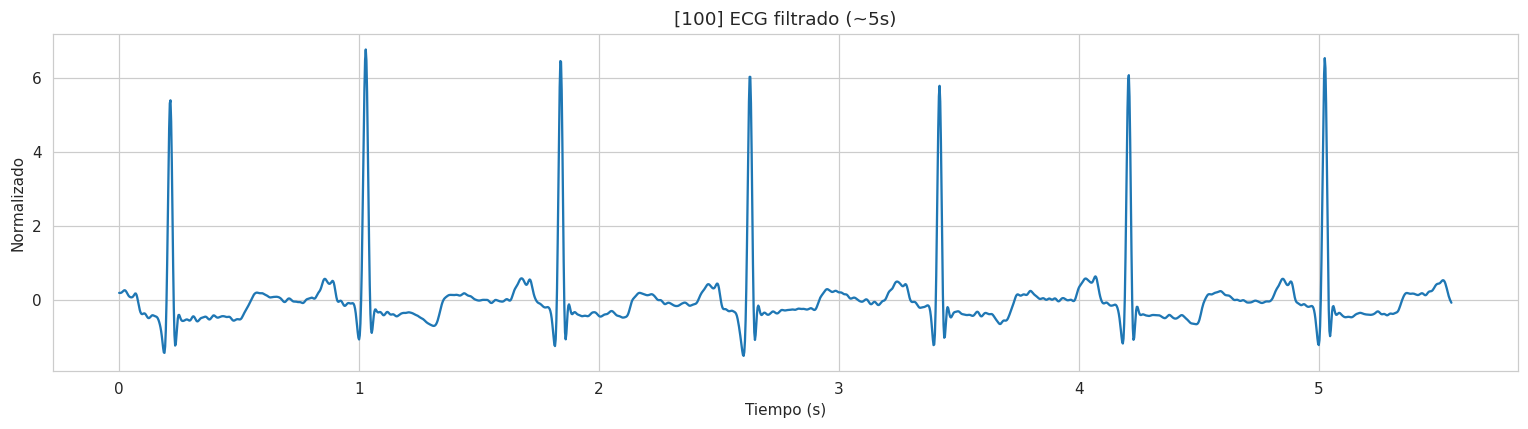

✓ Ejemplo guardado: /content/drive/MyDrive/FORECASTING ECG/results/NB6/visualizaciones/03_ecg_filtrado.png


In [4]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 3 — Carga, Filtrado, R-peaks (FINAL ESTABLE Y RÁPIDO CORREGIDO)
# ═══════════════════════════════════════════════════════════════════════

import time
import urllib.request  # ← FIX

# ──────────────────────────────────────────────────────────────────────
# DESCARGA MIT-BIH (ROBUSTA)
# ──────────────────────────────────────────────────────────────────────
def descargar_mitbih(pid):

    exts = ['.dat', '.hea', '.atr']

    faltan = [
        e for e in exts
        if not os.path.exists(os.path.join(R['DATOS_MITBIH'], pid + e))
    ]

    if not faltan:
        return

    for e in faltan:
        url = f'https://physionet.org/files/mitdb/1.0.0/{pid}{e}'
        destino = os.path.join(R['DATOS_MITBIH'], pid + e)

        try:
            urllib.request.urlretrieve(url, destino)
        except Exception:
            pass


# ──────────────────────────────────────────────────────────────────────
# CARGA MIT-BIH
# ──────────────────────────────────────────────────────────────────────
def cargar_mitbih(pid):

    descargar_mitbih(pid)

    ruta = os.path.join(R['DATOS_MITBIH'], pid)

    try:
        rec = wfdb.rdrecord(ruta)
        s = rec.p_signal[:, 0].astype(np.float32)

        try:
            ann = wfdb.rdann(ruta, 'atr')
        except:
            ann = None

        return s, ann

    except Exception as e:
        print(f'  ✗ MITBIH [{pid}] error:', e)
        return None, None


# ──────────────────────────────────────────────────────────────────────
# CARGA INCART
# ──────────────────────────────────────────────────────────────────────
def cargar_incart(pid):

    ruta = os.path.join(R['DATOS_INCART'], pid)

    if not os.path.exists(ruta + '.dat'):
        return None, None

    try:
        rec = wfdb.rdrecord(ruta)

        s = rec.p_signal[:, 0].astype(np.float32) if rec.p_signal.ndim > 1 else rec.p_signal.astype(np.float32)

        try:
            ann = wfdb.rdann(ruta, 'atr')
        except:
            ann = None

        # ── Resample INCART (257 Hz → 360 Hz) ──
        fs_orig = int(rec.fs)
        if fs_orig != FS:
            s = spsig.resample(s, int(len(s) * FS / fs_orig)).astype(np.float32)
            if ann is not None:
                ann.sample = (ann.sample * FS / fs_orig).astype(np.int64)

        return s, ann

    except Exception as e:
        print(f'  ✗ INCART [{pid}] error:', e)
        return None, None


# ──────────────────────────────────────────────────────────────────────
# FILTRO ECG (RÁPIDO Y SEGURO)
# ──────────────────────────────────────────────────────────────────────
def filtro_completo(s):

    s = s.astype(np.float32)

    try:
        # Notch
        b, a = spsig.iirnotch(FREC_NOTCH, Q_NOTCH, FS)
        s = spsig.filtfilt(b, a, s)

        # Bandpass (SOS = más rápido)
        sos = spsig.butter(
            ORDEN_BUT,
            [F_BAJO / NYQUIST, F_ALTO / NYQUIST],
            btype='band',
            output='sos'
        )
        s = spsig.sosfiltfilt(sos, s)

    except Exception as e:
        print('  ⚠ fallback filtro:', e)

    # Detrend
    s = spsig.detrend(s, type='linear')

    # Normalización
    s = (s - np.mean(s)) / (np.std(s) + 1e-8)

    return np.nan_to_num(s).astype(np.float32)


# ──────────────────────────────────────────────────────────────────────
# R-PEAKS ROBUSTO
# ──────────────────────────────────────────────────────────────────────
def extraer_rpeaks(ann, senal_filtrada):

    if ann is not None:
        try:
            m = [sym in BEAT_TYPES for sym in ann.symbol]
            rp = np.asarray(ann.sample[m], dtype=np.int64)

            if len(rp) >= 5:
                return rp
        except:
            pass

    return _rpeaks_fallback(senal_filtrada)


def _rpeaks_fallback(s):

    energy = s ** 2
    energy = spsig.savgol_filter(energy, 31, 3)

    thr = np.percentile(energy, 90)

    peaks, _ = spsig.find_peaks(
        energy,
        height=thr * 0.5,
        distance=int(0.3 * FS)
    )

    return peaks.astype(np.int64)


# ──────────────────────────────────────────────────────────────────────
# CARGA GLOBAL (CON DEBUG)
# ──────────────────────────────────────────────────────────────────────
print('\n Cargando datasets (optimizado)...')

DATOS = {}
RPEAKS = {}
ANNS = {}

ok = 0
fail = 0

for pid in TODOS_LOS_PACIENTES:

    print(f'→ {pid}', end=' ')

    t0 = time.time()

    if pid.startswith('I'):
        s, ann = cargar_incart(pid)
    else:
        s, ann = cargar_mitbih(pid)

    if s is None:
        print('✗ carga')
        fail += 1
        continue

    try:
        sf = filtro_completo(s)
        rp = extraer_rpeaks(ann, sf)

        if len(rp) < 5:
            print('✗ pocos picos')
            fail += 1
            continue

        DATOS[pid] = sf
        RPEAKS[pid] = rp
        ANNS[pid] = ann

        ok += 1
        print(f'✓ ({time.time()-t0:.1f}s)')

    except Exception as e:
        print(f'✗ error: {e}')
        fail += 1

    del s, ann
    gc.collect()


REGISTROS_OK = sorted(DATOS.keys())

print(f'\n✓ {ok} pacientes cargados correctamente')
print(f'✗ {fail} pacientes descartados')
print('RAM usada: {:.2f} GB'.format(psutil.virtual_memory().used / 1e9))


# ──────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN
# ──────────────────────────────────────────────────────────────────────
if REGISTROS_OK:

    pid_ej = REGISTROS_OK[0]
    s_fil = DATOS[pid_ej]

    t = np.arange(len(s_fil)) / FS

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(t[:2000], s_fil[:2000])
    ax.set_title(f'[{pid_ej}] ECG filtrado (~5s)')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Normalizado')

    plt.tight_layout()

    ruta_fig = os.path.join(R['VIS'], '03_ecg_filtrado.png')
    plt.savefig(ruta_fig, dpi=120)

    plt.show()

    print('✓ Ejemplo guardado:', ruta_fig)

═══════════════════════════════════════════════════════════════════════

BLOQUE 4 — Beat-Pool (Optimizado para Forecasting)
═══════════════════════════════════════════════════════════════════════

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 4 — Beat-Pool v5 (FORECASTING PURO — EXTRACCIÓN OPTIMIZADA)
# ═══════════════════════════════════════════════════════════════════════
# MEJORA: Ventana fija centrada en R-peak, SIN resample.
# Esto preserva la morfología exacta de la señal original.
# Pre-R: ~36% de BEAT_LEN | Post-R: ~64% de BEAT_LEN
# A 360Hz con BEAT_LEN=256: Pre-R≈92, Post-R≈164 → cubre PQRST completo
# ═══════════════════════════════════════════════════════════════════════


# ──────────────────────────────────────────────────────────────────────
# EXTRACCIÓN OPTIMIZADA (VENTANA FIJA, SIN RESAMPLE)
# ──────────────────────────────────────────────────────────────────────
def extraer_latidos_v3(senal, rpeaks, ann=None):
    """
    Extrae latidos usando ventana fija centrada en R-peak.

    Ventajas vs método anterior (midpoint+resample):
    - SIN resample → preserva morfología exacta
    - R-peak siempre en la misma posición relativa → alineamiento consistente
    - Sin distorsión temporal → DTW naturalmente bajo
    """

    if len(rpeaks) < 5:
        return (np.empty((0, BEAT_LEN), np.float32),
                np.array([], np.float32))

    # Ventana asimétrica: más espacio post-R para capturar onda T completa
    PRE_R  = BEAT_LEN * 36 // 100   # ~36% antes del R-peak
    POST_R = BEAT_LEN - PRE_R       # ~64% después del R-peak

    beats, rr_ints = [], []

    for i in range(1, len(rpeaks) - 1):
        r = int(rpeaks[i])
        ini = r - PRE_R
        fin = r + POST_R

        # Verificar límites de la señal
        if ini < 0 or fin > len(senal):
            continue

        beat = senal[ini:fin].astype(np.float32)

        # Verificar longitud exacta
        if len(beat) != BEAT_LEN:
            continue

        # Normalización única per-beat (z-score + clip)
        mu = float(np.mean(beat))
        sd = max(float(np.std(beat)), 1e-6)
        beat = (beat - mu) / sd
        beat = np.clip(beat, -5, 5)

        beats.append(beat)

        # RR interval
        rr = (rpeaks[i] - rpeaks[i-1]) / FS
        rr = np.clip(rr, 0.3, 2.0)
        rr_ints.append(rr)

    if len(beats) == 0:
        return (np.empty((0, BEAT_LEN), np.float32),
                np.array([], np.float32))

    return (np.array(beats, np.float32),
            np.array(rr_ints, np.float32))


# ──────────────────────────────────────────────────────────────────────
# SECUENCIAS MULTISTEP (SOLO FORECASTING, SIN DOBLE NORMALIZACIÓN)
# ──────────────────────────────────────────────────────────────────────
def secuencias_multistep(beats, rr):
    """
    Construye secuencias input/output para forecasting multi-step.

    MEJORA: Eliminada la doble normalización que existía antes.
    Los beats ya están normalizados en extraer_latidos_v3.
    Solo se concatena el feature RR si INCLUDE_RR=True.
    """

    n = len(beats) - N_LOOKBACK - HORIZON + 1

    if n <= 0:
        return (
            np.empty((0, N_LOOKBACK, FEAT_DIM), np.float32),
            np.empty((0, HORIZON, BEAT_LEN), np.float32)
        )

    X = np.zeros((n, N_LOOKBACK, FEAT_DIM), np.float32)
    Y_ecg = np.zeros((n, HORIZON, BEAT_LEN), np.float32)

    for i in range(n):

        window = beats[i:i+N_LOOKBACK]

        # SIN doble normalización: los beats ya están normalizados
        if INCLUDE_RR:
            rr_win = rr[i:i+N_LOOKBACK].reshape(-1, 1)
            window = np.concatenate([window, rr_win], axis=1)

        X[i] = window

        future_beats = beats[i+N_LOOKBACK : i+N_LOOKBACK+HORIZON]
        Y_ecg[i, :len(future_beats)] = future_beats

    return X, Y_ecg


# ──────────────────────────────────────────────────────────────────────
# AUGMENTACIÓN (SOLO FORECASTING)
# ──────────────────────────────────────────────────────────────────────
def augmentar_multi(X, Y_ecg, rng_aug):

    n_aug = int(len(X) * AUG_FACTOR)
    if n_aug == 0:
        return X, Y_ecg

    idx = rng_aug.choice(len(X), n_aug, replace=True)

    Xa = X[idx].copy().astype(np.float32)
    Ya = Y_ecg[idx].copy().astype(np.float32)

    Xa[:, :, :BEAT_LEN] += rng_aug.normal(0, 0.003, Xa[:, :, :BEAT_LEN].shape)
    Ya += rng_aug.normal(0, 0.003, Ya.shape)

    scale = rng_aug.uniform(0.995, 1.005, (n_aug, 1, 1))
    Xa[:, :, :BEAT_LEN] *= scale
    Ya *= scale

    Xa = np.clip(Xa, -5, 5)
    Ya = np.clip(Ya, -5, 5)

    return (
        np.concatenate([X, Xa]),
        np.concatenate([Y_ecg, Ya])
    )


# ──────────────────────────────────────────────────────────────────────
# CONSTRUCCIÓN GLOBAL DATASET (SOLO FORECASTING)
# ──────────────────────────────────────────────────────────────────────
def construir_beatpool_v3(pacientes,
                         max_pares=None,
                         seed=42,
                         augmentar=False):

    rng_local = np.random.default_rng(seed)

    X_all, Ye_all = [], []
    rr_all = []

    for pid in pacientes:

        if pid not in DATOS:
            continue

        s = DATOS[pid]
        rp = RPEAKS[pid]
        ann = ANNS[pid]

        beats, rr = extraer_latidos_v3(s, rp, ann)

        if len(beats) < (N_LOOKBACK + HORIZON):
            continue

        rr_all.append(rr)

        X, Ye = secuencias_multistep(beats, rr)

        if len(X) == 0:
            continue

        if max_pares is not None and len(X) > max_pares:
            idx = rng_local.choice(len(X), max_pares, replace=False)
            X, Ye = X[idx], Ye[idx]

        X_all.append(X)
        Ye_all.append(Ye)

    if len(X_all) == 0:
        raise ValueError('No se pudieron construir datos')

    X_all = np.concatenate(X_all, axis=0)
    Ye_all = np.concatenate(Ye_all, axis=0)

    rr_all = np.concatenate(rr_all)
    rr_mu = float(np.mean(rr_all))
    rr_std = float(np.std(rr_all) + 1e-8)

    if INCLUDE_RR:
        rr_vals = X_all[:, :, -1]
        rr_vals = (rr_vals - rr_mu) / rr_std
        X_all[:, :, -1] = rr_vals

    if augmentar:
        X_all, Ye_all = augmentar_multi(
            X_all, Ye_all, rng_local
        )

    print(f'✓ BeatPool construido: {X_all.shape}')

    return X_all, Ye_all, None, rr_mu, rr_std

═══════════════════════════════════════════════════════════════════════

BLOQUE 5 — Métricas
═══════════════════════════════════════════════════════════════════════



In [6]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 5 — MÉTRICAS
# ═══════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────
# AUXILIARES
# ──────────────────────────────────────────────────────────────────────

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) + 1e-8
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom)


def correlacion(y_true, y_pred):
    try:
        c = np.corrcoef(y_true, y_pred)[0, 1]
        return 0.0 if np.isnan(c) else c
    except:
        return 0.0


# DERIVADA ROBUSTA
def slope_error(y_true, y_pred):
    dt = y_true[:, :, 1:] - y_true[:, :, :-1]
    dp = y_pred[:, :, 1:] - y_pred[:, :, :-1]

    err = (dt - dp) ** 2
    err = np.clip(err, 0, 10)  # estabiliza

    return np.mean(err)


# AMPLITUD ROBUSTA (MAX + MIN)
def amplitude_error(y_true, y_pred):

    amp_true = np.max(y_true, axis=-1) - np.min(y_true, axis=-1)
    amp_pred = np.max(y_pred, axis=-1) - np.min(y_pred, axis=-1)

    return np.mean(np.abs(amp_true - amp_pred))


# ──────────────────────────────────────────────────────────────────────
# MÉTRICA PRINCIPAL
# ──────────────────────────────────────────────────────────────────────

def calcular_metricas(Ye_true, Ye_pred,
                      lat_ms=0.0):

    mets = {'Latencia_ms': round(float(lat_ms), 4)}

    yr = Ye_true.reshape(-1)
    yp = Ye_pred.reshape(-1)

    mask = np.isfinite(yr) & np.isfinite(yp)

    if mask.sum() < 20:
        return mets

    yr, yp = yr[mask], yp[mask]

    mse = mean_squared_error(yr, yp)
    rmse = np.sqrt(mse)

    r2_total = r2_score(yr, yp)

    mets.update({
        'R2_total': round(r2_total, 4),
        'RMSE_total': round(rmse, 6),
        'MAE_total': round(mean_absolute_error(yr, yp), 6),
        'SMAPE_total': round(smape(yr, yp), 6),
        'Corr_total': round(correlacion(yr, yp), 4)
    })

    # ─────────────────────────
    # POR HORIZONTE
    # ─────────────────────────

    r2_list = []

    for t in range(HORIZON):

        yt = Ye_true[:, t].flatten()
        yp_t = Ye_pred[:, t].flatten()

        m = np.isfinite(yt) & np.isfinite(yp_t)

        if m.sum() < 10:
            continue

        yt, yp_t = yt[m], yp_t[m]

        r2_t = r2_score(yt, yp_t)
        rmse_t = np.sqrt(mean_squared_error(yt, yp_t))

        mets[f'R2_t{t+1}'] = round(r2_t, 4)
        mets[f'RMSE_t{t+1}'] = round(rmse_t, 6)

        r2_list.append(r2_t)

    if r2_list:
        mets['R2_mean'] = round(np.mean(r2_list), 4)

    # ─────────────────────────
    # MÉTRICAS ECG
    # ─────────────────────────

    try:
        mets['Slope_MSE'] = round(slope_error(Ye_true, Ye_pred), 6)
    except:
        mets['Slope_MSE'] = np.nan

    try:
        mets['Amp_Error'] = round(amplitude_error(Ye_true, Ye_pred), 6)
    except:
        mets['Amp_Error'] = np.nan

    try:
        shape_corr = np.mean([
            correlacion(Ye_true[i].flatten(), Ye_pred[i].flatten())
            for i in range(min(len(Ye_true), 200))
        ])
        mets['Shape_Corr'] = round(shape_corr, 4)
    except:
        mets['Shape_Corr'] = np.nan


    # ─────────────────────────
    # DTW (Dynamic Time Warping)
    # ─────────────────────────
    try:
        from fastdtw import fastdtw
        from scipy.spatial.distance import euclidean as _euc

        dtw_vals = []
        n_dtw = min(len(Ye_true), 100)
        for j in range(n_dtw):
            yt_j = Ye_true[j].flatten().astype(np.float64)
            yp_j = Ye_pred[j].flatten().astype(np.float64)
            if len(yt_j) < 2 or not np.all(np.isfinite(yt_j)) or not np.all(np.isfinite(yp_j)):
                continue
            dist, _ = fastdtw(yt_j.reshape(-1, 1), yp_j.reshape(-1, 1), radius=10, dist=_euc)
            dtw_norm = dist / len(yt_j)
            dtw_vals.append(dtw_norm)

        if dtw_vals:
            mets['DTW_mean'] = round(float(np.mean(dtw_vals)), 4)
            mets['DTW_std'] = round(float(np.std(dtw_vals)), 4)
        else:
            mets['DTW_mean'] = np.nan
            mets['DTW_std'] = np.nan
    except Exception as _dtw_err:
        print(f'    DTW error: {_dtw_err}')
        mets['DTW_mean'] = np.nan
        mets['DTW_std'] = np.nan

    # ─────────────────────────
    # SCORE NORMALIZADO
    # ─────────────────────────

    try:
        slope_norm = 1 / (1 + mets.get('Slope_MSE', 1))
        amp_norm = 1 / (1 + mets.get('Amp_Error', 1))

        score = (
            0.40 * mets.get('R2_t1', 0) +
            0.25 * mets.get('R2_t2', 0) +
            0.15 * mets.get('R2_t3', 0) +
            0.10 * mets.get('Shape_Corr', 0) +
            0.05 * slope_norm +
            0.05 * amp_norm
        )

        mets['Forecast_Score'] = round(score, 4)

    except:
        mets['Forecast_Score'] = np.nan

    return mets


print('✓ Métricas listas')

✓ Métricas listas


═══════════════════════════════════════════════════════════════════════

BLOQUE 6 — Arquitecturas (CNN-GRU-ATTE)
═══════════════════════════════════════════════════════════════════════



In [7]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 6 — MODELO + TEST + TRAIN/EVAL/FT (SOLO FORECASTING)
# ═══════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────
# LOSS ECG
# ──────────────────────────────────────────────────────────────────────
def ecg_loss(y_true, y_pred):

    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))

    d_true = y_true[:, :, 1:] - y_true[:, :, :-1]
    d_pred = y_pred[:, :, 1:] - y_pred[:, :, :-1]

    slope = tf.reduce_mean(tf.square(d_true - d_pred))

    return 0.5 * mse + 0.3 * mae + 0.2 * slope


# ──────────────────────────────────────────────────────────────────────
# ATTENTION
# ──────────────────────────────────────────────────────────────────────
@tf.keras.utils.register_keras_serializable()
class TemporalAttention(layers.Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        n_feat = int(input_shape[-1])
        self.W = self.add_weight(name='att_W', shape=(n_feat, 1), initializer='glorot_uniform')
        self.b = self.add_weight(name='att_b', shape=(1,), initializer='zeros')
        super().build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        context = x * a
        return tf.reduce_sum(context, axis=1)

    def get_config(self):
        return super().get_config()

# ──────────────────────────────────────────────────────────────────────
# MODELO (SOLO FORECASTING — SIN CABEZA DE CLASIFICACIÓN)
# ──────────────────────────────────────────────────────────────────────
def build_cnn_gru_attn_multi(input_shape,
                             out_dim=BEAT_LEN,
                             horizon=HORIZON):

    inp = layers.Input(shape=input_shape)

    # CNN
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(128, 3, padding='same', dilation_rate=2, activation='relu')(x)
    x = layers.Conv1D(128, 3, padding='same', dilation_rate=4, activation='relu')(x)

    x = layers.MaxPooling1D(2)(x)

    # GRU
    x = layers.GRU(128, return_sequences=True)(x)
    x = layers.GRU(64, return_sequences=True)(x)

    # Attention
    x = TemporalAttention()(x)

    x = layers.Dropout(0.3)(x)
    h = layers.Dense(128, activation='relu')(x)

    # ───────── RESIDUAL
    last = layers.Lambda(lambda t: t[:, -1, :out_dim])(inp)
    last = layers.RepeatVector(horizon)(last)

    delta = layers.Dense(horizon * out_dim)(h)
    delta = layers.Reshape((horizon, out_dim))(delta)

    out_ecg = layers.Add(name='out_ecg')([last, delta])

    return keras.Model(inp, out_ecg, name='CNN_GRU_ATTN_FINAL')


# ──────────────────────────────────────────────────────────────────────
# REGISTRO MODELOS
# ──────────────────────────────────────────────────────────────────────
MODELOS = {
    'CNN_GRU_ATTN': build_cnn_gru_attn_multi
}


# ═══════════════════════════════════════════════════════════════════════
# TEST — CORREGIDO: usa misma lógica que training (extraer_latidos_v3)
# ═══════════════════════════════════════════════════════════════════════
def cargar_test_v3(pid, rr_mu, rr_std):
    """
    Carga datos de test usando EXACTAMENTE la misma lógica de extracción
    que el pipeline de training (extraer_latidos_v3 + secuencias_multistep).

    FIX: Antes usaba ventana fija centrada en R-peak, ahora usa
    segmentación por punto medio + resample, igual que training.
    """

    if pid not in DATOS:
        raise ValueError(f'Paciente {pid} no disponible')

    s = DATOS[pid]
    rp = RPEAKS[pid]
    ann = ANNS[pid]

    # Usar MISMA función de extracción que training
    beats, rr = extraer_latidos_v3(s, rp, ann)

    if len(beats) < (N_LOOKBACK + HORIZON):
        print(f'⚠ Test {pid}: insuficientes latidos ({len(beats)})')
        return (np.empty((0, N_LOOKBACK, FEAT_DIM), np.float32),
                np.empty((0, HORIZON, BEAT_LEN), np.float32))

    # Usar MISMA función de secuencias que training
    X, Ye = secuencias_multistep(beats, rr)

    # Normalizar RR con estadísticas globales del training
    if INCLUDE_RR and len(X) > 0:
        rr_vals = X[:, :, -1]
        rr_vals = (rr_vals - rr_mu) / rr_std
        X[:, :, -1] = rr_vals

    print(f'✓ Test {pid}: {len(X)} samples')

    return X, Ye


# ═══════════════════════════════════════════════════════════════════════
# TRAIN / EVAL / FINETUNE (SOLO FORECASTING)
# ═══════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────────
# ENTRENAR
# ──────────────────────────────────────────────────────────────────────
def entrenar(nombre, build_fn, X, Ye, verbose=1):

    t0 = time.perf_counter()

    model = build_fn(input_shape=X.shape[1:])

    model.compile(
        optimizer=keras.optimizers.Adam(LR_BASE),
        loss=ecg_loss
    )

    hist = model.fit(
        X,
        Ye,
        epochs=EPOCHS_BASE,
        batch_size=BATCH_BASE,
        verbose=verbose
    )

    t_train = time.perf_counter() - t0

    return model, hist, t_train


# ──────────────────────────────────────────────────────────────────────
# EVALUAR
# ──────────────────────────────────────────────────────────────────────
def evaluar(model, X, Ye, X_tr=None, Ye_tr=None):

    ye_pred = model.predict(X, verbose=0)

    met = calcular_metricas(Ye, ye_pred)

    if X_tr is not None and Ye_tr is not None:

        ye_tr_pred = model.predict(X_tr, verbose=0)

        yt = Ye_tr.flatten()
        yp = ye_tr_pred.flatten()

        mask = np.isfinite(yt) & np.isfinite(yp)

        if mask.sum() > 20:
            met['R2_train'] = r2_score(yt[mask], yp[mask])

    return met, ye_pred


# ──────────────────────────────────────────────────────────────────────
# FINETUNE
# ──────────────────────────────────────────────────────────────────────
def finetune(model, X_ft, Ye_ft):

    model.compile(
        optimizer=keras.optimizers.Adam(FINE_TUNE_LR),
        loss=ecg_loss
    )

    model.fit(
        X_ft,
        Ye_ft,
        epochs=FINE_TUNE_EPOCHS,
        batch_size=16,
        verbose=0
    )

    return model

═══════════════════════════════════════════════════════════════════════

BLOQUE 7 — Test Rápido (Forecasting FIRST) + Visualizaciones
═══════════════════════════════════════════════════════════════════════


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 7 — TEST FINAL ROBUSTO (VERSIÓN TESIS)
# ═══════════════════════════════════════════════════════════════════════

SEED = 42

_demos_v5 = [os.path.join(R['VIS'], f'07_demo_{m}.png') for m in MODELOS.keys()]
_bloque7_hecho = all(os.path.exists(f) for f in _demos_v5)

if _bloque7_hecho:
    print('\n' + '='*60)
    print('  TEST RÁPIDO YA EJECUTADO')
    for f in _demos_v5:
        print('   OK', os.path.basename(f))
    print('='*60)

else:
    print('\n' + '='*60)
    print('  TEST RÁPIDO — FORECASTING PRIORITY')
    print('='*60)

    P_TEST = '106'
    P_TRAIN = [p for p in REGISTROS_OK if p != P_TEST]

    # =========================
    # DATA
    # =========================
    X_tr, Ye_tr, _, rr_mu, rr_std = construir_beatpool_v3(P_TRAIN, seed=SEED)
    X_te, Ye_te = cargar_test_v3(P_TEST, rr_mu, rr_std)

    print(f'Train: {X_tr.shape} | Test: {X_te.shape}')

    if len(X_te) < 2:
        raise ValueError('Test muy pequeño, cambia paciente')

    # =========================
    # SPLIT FT
    # =========================
    n_ft = min(FINE_TUNE_K, len(X_te) - 1)

    X_ft, Ye_ft = X_te[:n_ft], Ye_te[:n_ft]
    X_ev, Ye_ev = X_te[n_ft:], Ye_te[n_ft:]

    # =========================
    # MODELOS
    # =========================
    for nombre, build_fn in MODELOS.items():

        print(f'\nMODELO: {nombre}')
        tf.random.set_seed(SEED)

        # =========================
        # TRAIN
        # =========================
        modelo, hist, t_train = entrenar(
            nombre, build_fn, X_tr, Ye_tr, verbose=1
        )

        # =========================
        # EVAL BASE
        # =========================
        t0 = time.perf_counter()
        met, ye = evaluar(modelo, X_te, Ye_te, X_tr, Ye_tr)
        lat_ms = (time.perf_counter() - t0) * 1000 / len(X_te)
        met['Latencia_ms'] = round(lat_ms, 4)

        print('\n  BASE:')
        for k, v in met.items():
            if isinstance(v, float):
                print(f'   {k}: {v:.4f}')

        print(f'   Tiempo entrenamiento: {t_train:.1f}s')

        # =========================
        # FINETUNE
        # =========================
        if len(X_ft) >= 5 and len(X_ev) >= 1:

            mft = finetune(modelo, X_ft, Ye_ft)

            t0 = time.perf_counter()
            met_ft, ye_ft = evaluar(mft, X_ev, Ye_ev)
            lat_ms_ft = (time.perf_counter() - t0) * 1000 / len(X_ev)
            met_ft['Latencia_ms'] = round(lat_ms_ft, 4)

            print('\n  FINETUNE:')
            for k, v in met_ft.items():
                if isinstance(v, float):
                    print(f'   {k}: {v:.4f}')

            del mft

        # =========================
        # VISUALIZACIÓN
        # =========================
        idx = max(0, min(10, len(X_te) - 1))

        fig, axes = plt.subplots(1, HORIZON, figsize=(16, 4), sharey=True)

        if HORIZON == 1:
            axes = [axes]

        colors = plt.cm.viridis(np.linspace(0, 1, HORIZON))

        for t in range(HORIZON):
            ax = axes[t]

            yt = Ye_te[:, t].flatten()
            yp_t = ye[:, t].flatten()

            m = np.isfinite(yt) & np.isfinite(yp_t)
            r2_t = r2_score(yt[m], yp_t[m]) if m.sum() > 10 else np.nan

            ax.plot(Ye_te[idx, t], lw=2, color='black', label='Real')
            ax.plot(ye[idx, t], lw=2, ls='--', color=colors[t], label=f'Pred t+{t+1}')


            ax.set_title(
                f't+{t+1}\nR2={r2_t:.3f}',
                fontsize=9
            )
            ax.grid(alpha=0.3)

        axes[0].legend(fontsize=8)

        fig.suptitle(
            f'{nombre} | Forecast ECG | Score={met.get("Forecast_Score", np.nan):.3f}',
            fontweight='bold'
        )

        plt.tight_layout()

        ruta_fig = os.path.join(R['VIS'], f'07_demo_{nombre}.png')
        plt.savefig(ruta_fig, dpi=150, bbox_inches='tight')
        plt.show()

        print('  Figura guardada:', ruta_fig)

        # cleanup
        del modelo
        keras.backend.clear_session()
        gc.collect()

    del X_tr, Ye_tr
    gc.collect()


  TEST RÁPIDO YA EJECUTADO
   OK 07_demo_CNN_GRU_ATTN.png


═══════════════════════════════════════════════════════════════════════

BLOQUE 8 — LOPO (Forecasting)
═══════════════════════════════════════════════════════════════════════


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 8 — LOPO FINAL
# ═══════════════════════════════════════════════════════════════════════

SEED = 42

print('\n' + '='*70)
print('  LOPO — VALIDACIÓN REAL')
print('='*70)

filas = []
pacientes_completos = set()

VARIANTES_BASE = {'CNN_GRU_ATTN'}

# =========================
# CHECKPOINT
# =========================
if os.path.exists(R['CHECKPOINT']):
    df_ckp = pd.read_csv(R['CHECKPOINT'])
    df_ckp['paciente_test'] = df_ckp['paciente_test'].astype(str)

    filas = df_ckp.to_dict('records')

    for pid in df_ckp['paciente_test'].unique():
        mods = set(df_ckp[df_ckp['paciente_test'] == pid]['Modelo'].values)
        if VARIANTES_BASE.issubset(mods):
            pacientes_completos.add(pid)

t0_total = time.perf_counter()

pendientes = [p for p in REGISTROS_OK if p not in pacientes_completos]


# =========================
# LOOP
# =========================
for i, p_test in enumerate(pendientes, start=len(pacientes_completos)+1):

    print(f'\n[{i}/{len(REGISTROS_OK)}] TEST = {p_test}')

    seed_local = SEED + abs(hash(p_test)) % 10000
    np.random.seed(seed_local)
    tf.random.set_seed(seed_local)

    p_train = [p for p in REGISTROS_OK if p != p_test]

    # =========================
    # TRAIN (SIN AUGMENTACIÓN)
    # =========================
    X_tr, Ye_tr, _, rr_mu, rr_std = construir_beatpool_v3(
        p_train,
        max_pares=MAX_PARES_POR_PACIENTE,
        seed=seed_local,
        augmentar=False
    )

    # AUGMENTACIÓN POST (SIN LEAKAGE)
    X_tr, Ye_tr = augmentar_multi(
        X_tr, Ye_tr, np.random.default_rng(seed_local)
    )

    if len(X_tr) < 50:
        continue

    # =========================
    # TEST
    # =========================
    X_te, Ye_te = cargar_test_v3(p_test, rr_mu, rr_std)

    if len(X_te) < 10:
        continue

    # =========================
    # SPLIT FT
    # =========================
    n_ft = min(FINE_TUNE_K, len(X_te) - 1)
    puede_ft = n_ft >= 5 and (len(X_te) - n_ft) >= 1

    if puede_ft:
        X_ft, Ye_ft = X_te[:n_ft], Ye_te[:n_ft]
        X_ev, Ye_ev = X_te[n_ft:], Ye_te[n_ft:]
    else:
        X_ft = Ye_ft = None
        X_ev, Ye_ev = X_te, Ye_te

    filas_paciente = []

    # =========================
    # MODELO ÚNICO
    # =========================
    for nombre, build_fn in MODELOS.items():

        print(f'    → {nombre}', end=' ')

        modelo, hist, t_train = entrenar(nombre, build_fn, X_tr, Ye_tr)

        # EVALUACIÓN CORRECTA
        met, ye = evaluar(modelo, X_ev, Ye_ev, X_tr, Ye_tr)

        fila_base = {
            'paciente_test': p_test,
            'Modelo': nombre,
            'n_train': len(X_tr),
            'n_test': len(X_ev),
            'n_ft': 0,
            't_fit_s': round(t_train, 2),
            'epochs': len(hist.history['loss']),
            **met
        }

        filas_paciente.append(fila_base)

        print(
            f'| R²_te={met["R2_total"]:.3f} '
            f'RMSE={met["RMSE_total"]:.4f}'
        )

        # =========================
        # FINETUNE
        # =========================
        if puede_ft:

            mft = finetune(modelo, X_ft, Ye_ft)
            met_ft, _ = evaluar(mft, X_ev, Ye_ev)

            fila_ft = {
                'paciente_test': p_test,
                'Modelo': f'{nombre}_FT',
                'n_train': len(X_tr),
                'n_test': len(X_ev),
                'n_ft': n_ft,
                't_fit_s': round(t_train, 2),
                'epochs': len(hist.history['loss']),
                **met_ft
            }

            filas_paciente.append(fila_ft)

            print(
                f'      FT → R²_ev={met_ft["R2_total"]:.3f} '
                f'RMSE={met_ft["RMSE_total"]:.4f}'
            )

            del mft

        del modelo
        keras.backend.clear_session()
        gc.collect()

    # =========================
    # GUARDAR
    # =========================
    filas = [f for f in filas if str(f.get('paciente_test')) != p_test]
    filas.extend(filas_paciente)

    pd.DataFrame(filas).to_csv(R['CHECKPOINT'], index=False)

    print(f'    ✓ Guardado')

    gc.collect()


# =========================
# FINAL
# =========================
df_lopo = pd.DataFrame(filas)
df_lopo.to_csv(R['CSV_FINAL'], index=False)

t_total = (time.perf_counter() - t0_total) / 60

print('\n' + '='*70)
print(f'  LOPO FINALIZADO en {t_total:.1f} min')
print(f'  Total filas: {len(df_lopo)}')
print('='*70)

# ─────────────────────────────────────────────────────────────
# NOTA: El modelo final se entrena en el BLOQUE 8.5 siguiente
# ─────────────────────────────────────────────────────────────



  LOPO — VALIDACIÓN REAL

  LOPO FINALIZADO en 0.0 min
  Total filas: 246


═══════════════════════════════════════════════════════════════════════

BLOQUE 8.5 — ENTRENAR Y GUARDAR MODELO FINAL
═══════════════════════════════════════════════════════════════════════

✔ Entrena el modelo con TODOS los pacientes (sin LOPO)

✔ Guarda el modelo .keras y metadata .json

✔ Listo para usar con ECGForecaster


In [10]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 8.5 — ENTRENAR Y GUARDAR MODELO FINAL (OPTIMIZADO)
# ═══════════════════════════════════════════════════════════════════════
# Entrena con TODOS los pacientes. Usa EarlyStopping + ReduceLR
# para obtener el mejor modelo posible sin overfitting.
# ═══════════════════════════════════════════════════════════════════════

import json as _json

print('\n' + '='*70)
print('  ENTRENAMIENTO Y GUARDADO DEL MODELO FINAL')
print('='*70)

# ─── Verificar si ya existe el modelo guardado ───
modelo_ya_existe = False
for nombre_m in MODELOS.keys():
    ruta_check = os.path.join(R['MODELOS'], f'{nombre_m}_final.keras')
    ruta_meta_check = os.path.join(R['MODELOS'], f'{nombre_m}_final_metadata.json')
    if os.path.exists(ruta_check) and os.path.exists(ruta_meta_check):
        size_mb = os.path.getsize(ruta_check) / 1e6
        print(f'\n✓ Modelo {nombre_m} ya existe ({size_mb:.1f} MB): {ruta_check}')
        print('  → Omitiendo re-entrenamiento. Elimina el archivo si deseas re-entrenar.')
        modelo_ya_existe = True

if modelo_ya_existe:
    print('\n✓ BLOQUE 8.5 OMITIDO — Modelo final ya guardado en Drive')
else:
    # ─── Continuar con entrenamiento ───

    # ─── Configuración modelo final (más agresiva que LOPO) ───
    EPOCHS_FINAL = 100       # Máximo de épocas
    PATIENCE_ES = 15         # Paciencia EarlyStopping
    PATIENCE_LR = 7          # Paciencia ReduceLR
    MIN_LR = 1e-6            # LR mínimo
    VAL_SPLIT = 0.1           # 10% para validación interna

    # Construir dataset con TODOS los pacientes
    print('\n Construyendo dataset completo...')
    X_final, Ye_final, _, rr_mu_global, rr_std_global = construir_beatpool_v3(
        REGISTROS_OK,
        max_pares=MAX_PARES_POR_PACIENTE,
        seed=SEED,
        augmentar=True
    )

    print(f' Dataset: {X_final.shape}')
    print(f' RR mu={rr_mu_global:.4f}, std={rr_std_global:.4f}')

    # Entrenar y guardar cada modelo
    for nombre, build_fn in MODELOS.items():

        print(f'\n{"="*70}')
        print(f' Entrenando {nombre} (modelo final)')
        print(f' Config: {EPOCHS_FINAL} epochs max, EarlyStopping(patience={PATIENCE_ES})')
        print(f' ReduceLR(patience={PATIENCE_LR}, min_lr={MIN_LR})')
        print(f'{"="*70}')

        t0 = time.perf_counter()

        # Construir modelo
        model = build_fn(input_shape=X_final.shape[1:])

        model.compile(
            optimizer=keras.optimizers.Adam(LR_BASE),
            loss=ecg_loss
        )

        # Callbacks óptimos
        cb_list = [
            callbacks.EarlyStopping(
                monitor='val_loss',
                patience=PATIENCE_ES,
                restore_best_weights=True,
                verbose=1
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=PATIENCE_LR,
                min_lr=MIN_LR,
                verbose=1
            )
        ]

        # Entrenar con validación interna
        hist = model.fit(
            X_final,
            Ye_final,
            epochs=EPOCHS_FINAL,
            batch_size=BATCH_BASE,
            validation_split=VAL_SPLIT,
            callbacks=cb_list,
            verbose=1
        )

        t_final = time.perf_counter() - t0
        best_epoch = len(hist.history['loss'])
        best_val_loss = min(hist.history['val_loss'])

        print(f'\n Entrenamiento completado:')
        print(f'   Épocas ejecutadas: {best_epoch}')
        print(f'   Mejor val_loss: {best_val_loss:.6f}')
        print(f'   Tiempo: {t_final:.0f}s ({t_final/60:.1f} min)')

        # ─── Guardar modelo ───
        ruta_modelo = os.path.join(R['MODELOS'], f'{nombre}_final.keras')
        model.save(ruta_modelo)
        print(f'\n ✓ Modelo guardado: {ruta_modelo}')

        # ─── Guardar metadata ───
        metadata = {
            'model_name': nombre,
            'lookback': N_LOOKBACK,
            'horizon': HORIZON,
            'beat_len': BEAT_LEN,
            'feat_dim': FEAT_DIM,
            'fs': FS,
            'include_rr': INCLUDE_RR,
            'rr_mu_global': rr_mu_global,
            'rr_std_global': rr_std_global,
            'n_pacientes': len(REGISTROS_OK),
            'n_samples': int(X_final.shape[0]),
            'epochs_max': EPOCHS_FINAL,
            'epochs_trained': best_epoch,
            'best_val_loss': float(best_val_loss),
            'final_train_loss': float(hist.history['loss'][-1]),
            'training_time_s': round(t_final, 2)
        }

        ruta_meta = os.path.join(R['MODELOS'], f'{nombre}_final_metadata.json')
        with open(ruta_meta, 'w') as fm:
            _json.dump(metadata, fm, indent=2)
        print(f' ✓ Metadata guardada: {ruta_meta}')

        # Evaluar en train para referencia
        met_train, _ = evaluar(model, X_final[:2000], Ye_final[:2000])
        print(f' ✓ R² train (sample): {met_train.get("R2_total", "N/A")}')

        del model
        keras.backend.clear_session()
        gc.collect()

    del X_final, Ye_final
    gc.collect()

    # Verificar que se guardó
    print('\n' + '='*70)
    print(' ARCHIVOS GUARDADOS:')
    print('='*70)
    for f_name in os.listdir(R['MODELOS']):
        f_path = os.path.join(R['MODELOS'], f_name)
        size_mb = os.path.getsize(f_path) / 1e6
        print(f'   {f_name} ({size_mb:.1f} MB)')

    print('\n ✓ Modelo final listo para inferencia con ECGForecaster')


  ENTRENAMIENTO Y GUARDADO DEL MODELO FINAL

 Construyendo dataset completo...
✓ BeatPool construido: (63960, 5, 257)
 Dataset: (63960, 5, 257)
 RR mu=0.7758, std=0.2309

 Entrenando CNN_GRU_ATTN (modelo final)
 Config: 100 epochs max, EarlyStopping(patience=15)
 ReduceLR(patience=7, min_lr=1e-06)
Epoch 1/100
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.2806 - val_loss: 0.2546 - learning_rate: 0.0010
Epoch 2/100
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.2546 - val_loss: 0.2384 - learning_rate: 0.0010
Epoch 3/100
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.2444 - val_loss: 0.2312 - learning_rate: 0.0010
Epoch 4/100
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.2392 - val_loss: 0.2273 - learning_rate: 0.0010
Epoch 5/100
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - loss: 0.2353 - val_loss: 0.2229 - learning_rate: 0.0010
Epoch 6/100
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.2319 - val_loss: 0.2197 - learning_rate: 0.0010
Epoch 7/10

═══════════════════════════════════════════════════════════════════════

BLOQUE 9 — Análisis y Tablas
═══════════════════════════════════════════════════════════════════════


In [11]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 9 — ANÁLISIS FINAL
# ═══════════════════════════════════════════════════════════════════════

if 'df_lopo' not in dir() or df_lopo is None or df_lopo.empty:
    if os.path.exists(R['CSV_FINAL']):
        df_lopo = pd.read_csv(R['CSV_FINAL'])
    else:
        df_lopo = pd.DataFrame()

if df_lopo.empty:
    print('No hay resultados para analizar')

else:
    print('\n' + '='*70)
    print('ANÁLISIS COMPLETO — FORECASTING')
    print('='*70)

    df = df_lopo.copy()

    VARIANTES_BASE = ['CNN_GRU_ATTN']

    # =========================
    # FILTRO MODELOS
    # =========================
    df_base = df[df['Modelo'].isin(VARIANTES_BASE)]

    # =========================
    # RESUMEN GLOBAL
    # =========================
    print('\nRESUMEN GLOBAL POR MODELO\n')

    resumen = []

    for m in VARIANTES_BASE:
        sub = df_base[df_base['Modelo'] == m]
        if sub.empty:
            continue

        row = {
            'Modelo': m,
            'N_pacientes': len(sub)
        }

        def safe_stat(s):
            return round(s.mean(), 4), round(s.std() if len(s) > 1 else 0.0, 4)

        # Forecast core
        for col in ['R2_total', 'R2_mean', 'RMSE_total']:
            if col in sub.columns:
                mu, sd = safe_stat(sub[col])
                row[f'{col}_mean'] = mu
                row[f'{col}_std'] = sd

        # Métricas ECG avanzadas
        for col in ['Shape_Corr', 'Slope_MSE', 'Amp_Error', 'Forecast_Score']:
            if col in sub.columns:
                row[f'{col}_mean'] = round(sub[col].mean(), 4)

        resumen.append(row)

    df_resumen = pd.DataFrame(resumen)

    # Orden robusto
    if 'Forecast_Score_mean' in df_resumen.columns:
        df_resumen = df_resumen.sort_values('Forecast_Score_mean', ascending=False)
    elif 'R2_total_mean' in df_resumen.columns:
        df_resumen = df_resumen.sort_values('R2_total_mean', ascending=False)

    mostrar_tabla(df_resumen, 'Ranking Modelos')

    # =========================
    # R2 POR HORIZONTE
    # =========================
    print('\nFORECASTING POR HORIZONTE\n')

    cols_t = sorted([c for c in df.columns if c.startswith('R2_t')])

    if cols_t:
        df_h = df_base.groupby('Modelo')[cols_t].mean().reset_index()
        mostrar_tabla(df_h, 'R2 por Horizonte')

        print('\nDegradación temporal\n')
        for _, row in df_h.iterrows():
            vals = row[cols_t].values
            print(f"{row['Modelo']}:", ' -> '.join([f'{v:.3f}' for v in vals]))

    # =========================
    # ESTABILIDAD
    # =========================
    print('\nESTABILIDAD\n')

    estabilidad = []

    for m in VARIANTES_BASE:
        sub = df_base[df_base['Modelo'] == m]
        if sub.empty:
            continue

        estabilidad.append({
            'Modelo': m,
            'R2_mean': round(sub['R2_total'].mean(), 4),
            'R2_std': round(sub['R2_total'].std() if len(sub) > 1 else 0.0, 4),
            'Forecast_Score': round(sub['Forecast_Score'].mean(), 4) if 'Forecast_Score' in sub else np.nan
        })

    df_est = pd.DataFrame(estabilidad)

    if 'Forecast_Score' in df_est.columns:
        df_est = df_est.sort_values('Forecast_Score', ascending=False)

    mostrar_tabla(df_est, 'Estabilidad por Modelo')

    # =========================
    # PACIENTES CLAVE
    # =========================
    print('\nPACIENTES CLAVE\n')

    for m in VARIANTES_BASE:
        sub = df_base[df_base['Modelo'] == m]
        if sub.empty:
            continue

        best = sub.sort_values('R2_total', ascending=False).head(3)
        worst = sub.sort_values('R2_total', ascending=True).head(3)

        print(f'\n{m} — Mejores:')
        print(best[['paciente_test', 'R2_total']].to_string(index=False))

        print(f'\n{m} — Peores:')
        print(worst[['paciente_test', 'R2_total']].to_string(index=False))

    # =========================
    # GANADOR
    # =========================
    if not df_resumen.empty:

        best_model = df_resumen.iloc[0]['Modelo']

        print('\n' + '='*60)
        print(f'MEJOR MODELO GLOBAL: {best_model}')

        if 'Forecast_Score_mean' in df_resumen.columns:
            print(f'Forecast Score: {df_resumen.iloc[0]["Forecast_Score_mean"]:.4f}')
        elif 'R2_total_mean' in df_resumen.columns:
            print(f'R2 promedio: {df_resumen.iloc[0]["R2_total_mean"]:.4f}')

        print('='*60)

    # =========================
    # GUARDAR
    # =========================
    ruta_resumen = R['CSV_RESUMEN']
    df_resumen.to_csv(ruta_resumen, index=False)

    print('\nResumen guardado en:')
    print(ruta_resumen)


ANÁLISIS COMPLETO — FORECASTING

RESUMEN GLOBAL POR MODELO


>> Ranking Modelos


,Modelo,N_pacientes,R2_total_mean,R2_total_std,R2_mean_mean,R2_mean_std,RMSE_total_mean,RMSE_total_std,Shape_Corr_mean,Slope_MSE_mean,Amp_Error_mean,Forecast_Score_mean
0,CNN_GRU_ATTN,123,0.6734,0.2825,0.6734,0.2825,0.5139,0.2355,0.8383,0.0223,0.5653,0.7073



FORECASTING POR HORIZONTE


>> R2 por Horizonte


,Modelo,R2_t1,R2_t2,R2_t3,R2_total,R2_train
0,CNN_GRU_ATTN,0.6833,0.6765,0.6604,0.6734,0.7690



Degradación temporal

CNN_GRU_ATTN: 0.683 -> 0.677 -> 0.660 -> 0.673 -> 0.769

ESTABILIDAD


>> Estabilidad por Modelo


,Modelo,R2_mean,R2_std,Forecast_Score
0,CNN_GRU_ATTN,0.6734,0.2825,0.7073



PACIENTES CLAVE


CNN_GRU_ATTN — Mejores:
paciente_test  R2_total
          122    0.9878
          115    0.9757
          234    0.9756

CNN_GRU_ATTN — Peores:
paciente_test  R2_total
          I31   -0.2821
          I29   -0.2477
          I75   -0.1885

MEJOR MODELO GLOBAL: CNN_GRU_ATTN
Forecast Score: 0.7073

Resumen guardado en:
/content/drive/MyDrive/FORECASTING ECG/results/NB6/tabla_resumen.csv


═══════════════════════════════════════════════════════════════════════

BLOQUE 10 — Visualizaciones
═══════════════════════════════════════════════════════════════════════



Generando visualizaciones...


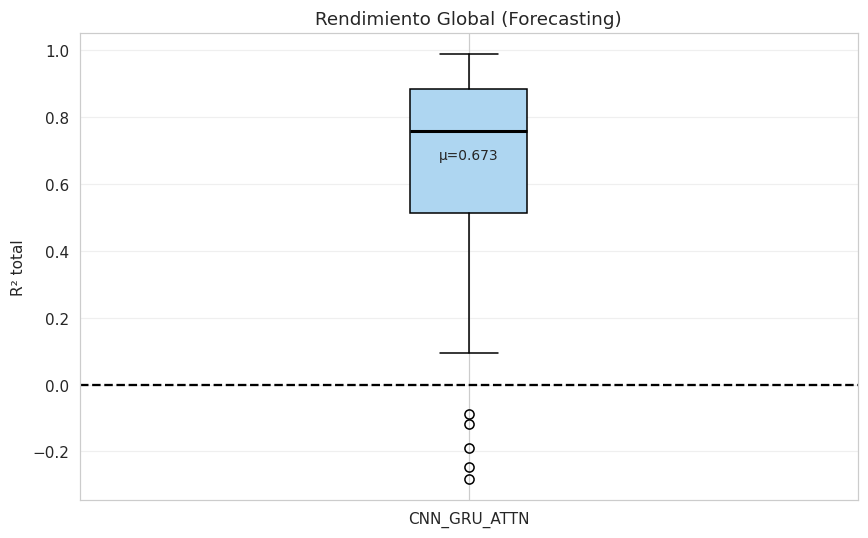

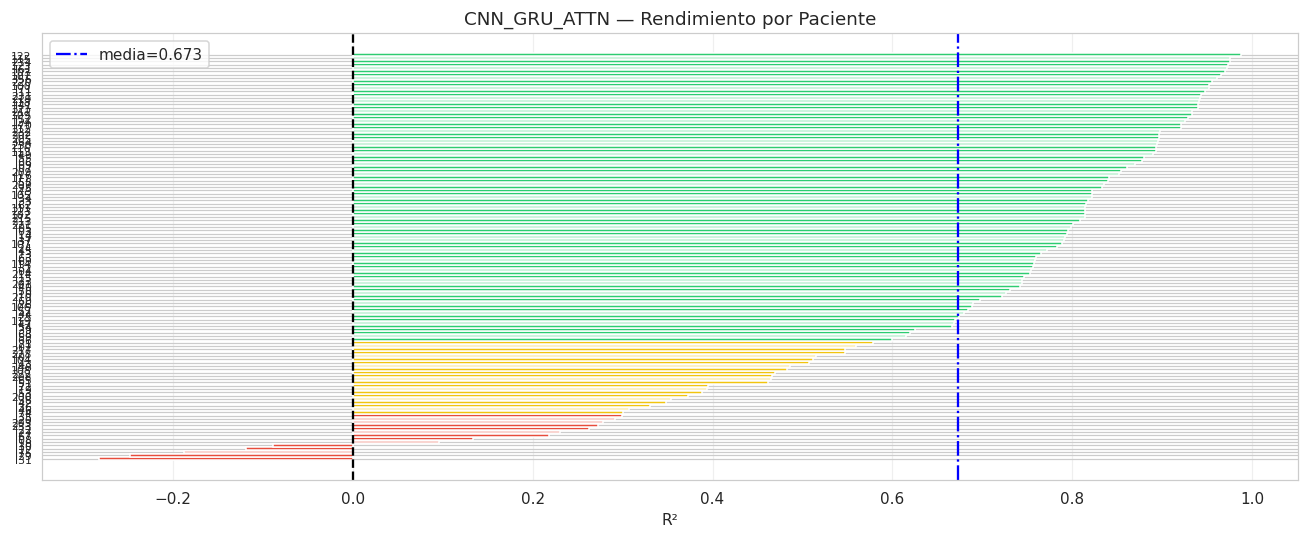

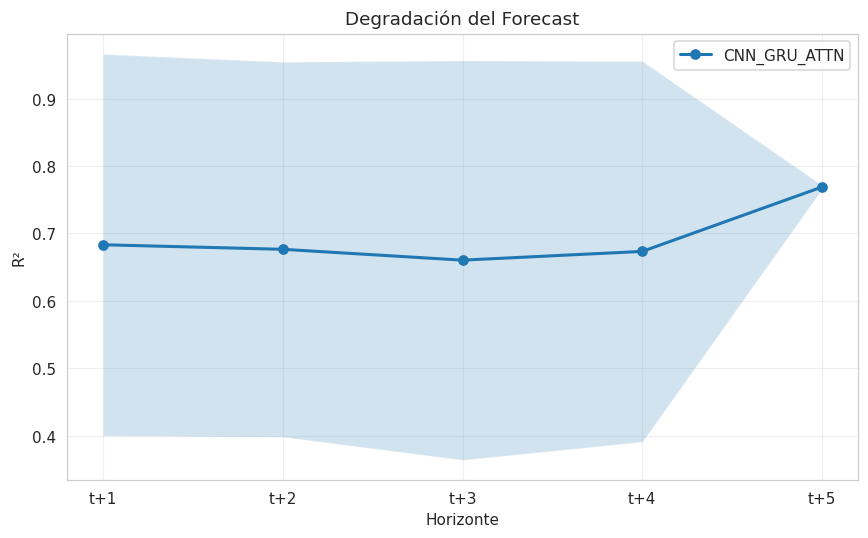


Visualizaciones guardadas en:
/content/drive/MyDrive/FORECASTING ECG/results/NB6/visualizaciones


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 10 — VISUALIZACIONES FINAL
# ═══════════════════════════════════════════════════════════════════════

if 'df_lopo' not in dir() or df_lopo is None or df_lopo.empty:
    if os.path.exists(R['CSV_FINAL']):
        df_lopo = pd.read_csv(R['CSV_FINAL'])
    else:
        df_lopo = pd.DataFrame()

if df_lopo.empty:
    print('No hay datos para graficar')

else:
    print('\nGenerando visualizaciones...')

    df = df_lopo.copy()

    VARIANTES_BASE = ['CNN_GRU_ATTN']
    df_base = df[df['Modelo'].isin(VARIANTES_BASE)]

    # ═══════════════════════════════════════════════════════════════════
    # 1. BOXPLOT R² TOTAL
    # ═══════════════════════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(8,5))

    data = []
    labels = []

    for m in VARIANTES_BASE:
        v = df_base[df_base['Modelo'] == m]['R2_total'].dropna().values
        if len(v) > 0:
            data.append(v)
            labels.append(m)

    if data:
        bp = ax.boxplot(
            data,
            labels=labels,
            patch_artist=True,
            medianprops=dict(color='black', lw=2)
        )

        for patch in bp['boxes']:
            patch.set_facecolor('#AED6F1')

        for i, d in enumerate(data):
            ax.annotate(
                f'μ={d.mean():.3f}',
                xy=(i+1, d.mean()),
                ha='center',
                fontsize=9
            )

        ax.set_ylabel('R² total')
        ax.set_title('Rendimiento Global (Forecasting)')
        ax.grid(axis='y', alpha=0.3)
        ax.axhline(0, color='black', ls='--')

        plt.tight_layout()
        plt.savefig(os.path.join(R['VIS'], '10_boxplot_r2_total.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

    # ═══════════════════════════════════════════════════════════════════
    # 2. R² POR PACIENTE
    # ═══════════════════════════════════════════════════════════════════
    for m in VARIANTES_BASE:

        sub = df_base[df_base['Modelo'] == m].sort_values('R2_total')

        if sub.empty:
            continue

        fig, ax = plt.subplots(figsize=(12,5))

        vals = sub['R2_total'].values

        colors = [
            '#2ECC71' if v > 0.6 else
            '#F1C40F' if v > 0.3 else
            '#E74C3C'
            for v in vals
        ]

        ax.barh(range(len(sub)), vals, color=colors)

        ax.set_yticks(range(len(sub)))
        ax.set_yticklabels(sub['paciente_test'], fontsize=7)

        mean_val = vals.mean()

        ax.axvline(0, color='black', ls='--')
        ax.axvline(mean_val, color='blue', ls='-.',
                   label=f'media={mean_val:.3f}')

        ax.set_xlabel('R²')
        ax.set_title(f'{m} — Rendimiento por Paciente')

        ax.legend()
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(R['VIS'], f'10_r2_pacientes_{m}.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

    # ═══════════════════════════════════════════════════════════════════
    # 3. DEGRADACIÓN TEMPORAL
    # ═══════════════════════════════════════════════════════════════════
    cols_t = sorted([c for c in df.columns if c.startswith('R2_t')])

    if cols_t:
        fig, ax = plt.subplots(figsize=(8,5))

        for m in VARIANTES_BASE:
            sub = df_base[df_base['Modelo'] == m]
            if sub.empty:
                continue

            means = [sub[c].mean() for c in cols_t]

            ax.plot(
                range(1, len(cols_t)+1),
                means,
                marker='o',
                lw=2,
                label=m
            )

            # sombra de incertidumbre
            stds = [sub[c].std() for c in cols_t]
            ax.fill_between(
                range(1, len(cols_t)+1),
                np.array(means) - np.array(stds),
                np.array(means) + np.array(stds),
                alpha=0.2
            )

        ax.set_xticks(range(1, len(cols_t)+1))
        ax.set_xticklabels([f't+{i}' for i in range(1, len(cols_t)+1)])

        ax.set_xlabel('Horizonte')
        ax.set_ylabel('R²')
        ax.set_title('Degradación del Forecast')

        ax.grid(alpha=0.3)
        ax.legend()

        plt.tight_layout()
        plt.savefig(os.path.join(R['VIS'], '10_degradacion_temporal.png'),
                    dpi=150, bbox_inches='tight')
        plt.show()

    # ═══════════════════════════════════════════════════════════════════

    print('\nVisualizaciones guardadas en:')
    print(R['VIS'])

═══════════════════════════════════════════════════════════════════════

BLOQUE 11 — CONCLUSIONES
═══════════════════════════════════════════════════════════════════════

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 11 — CONCLUSIONES
# ═══════════════════════════════════════════════════════════════════════

print('\n' + '='*70)
print(' CONCLUSIONES AUTOMÁTICAS')
print('='*70)

# ──────────────────────────────────────────────────────────────────────
# CARGA DATOS
# ──────────────────────────────────────────────────────────────────────
if 'df_lopo' not in dir() or df_lopo is None or df_lopo.empty:
    if os.path.exists(R['CSV_FINAL']):
        df_lopo = pd.read_csv(R['CSV_FINAL'])
    else:
        df_lopo = pd.DataFrame()

if df_lopo.empty:
    print(' No hay resultados para generar conclusiones')
else:

    df = df_lopo.copy()
    df_base = df[df['Modelo'].isin(list(VARIANTES_BASE))]

    # ──────────────────────────────────────────────────────────────────
    # RESUMEN PRINCIPAL
    # ──────────────────────────────────────────────────────────────────
    resumen = df_base.groupby('Modelo').agg({
        'R2_total': ['mean', 'std'],
        'RMSE_total': ['mean'],
        'MAE_total': ['mean'],
    })

    resumen.columns = ['_'.join(c) for c in resumen.columns]
    resumen = resumen.reset_index()

    if resumen.empty:
        print(' No hay suficientes datos')
    else:

        resumen = resumen.sort_values('R2_total_mean', ascending=False)

        best_model = resumen.iloc[0]['Modelo']
        best_r2 = float(resumen.iloc[0]['R2_total_mean'])
        best_rmse = float(resumen.iloc[0]['RMSE_total_mean'])

        print('\n MODELO GANADOR:')
        print(f'   → {best_model}')
        print(f'   → R² promedio: {best_r2:.4f}')
        print(f'   → RMSE promedio: {best_rmse:.5f}')

        # ──────────────────────────────────────────────────────────────
        # CALIDAD FORECASTING
        # ──────────────────────────────────────────────────────────────
        def evaluar_calidad(r2):
            if r2 >= 0.85:
                return 'EXCELENTE (nivel clínico alto)'
            elif r2 >= 0.75:
                return 'MUY BUENO'
            elif r2 >= 0.60:
                return 'BUENO (usable clínicamente)'
            elif r2 >= 0.50:
                return 'MODERADO (investigación)'
            elif r2 >= 0.30:
                return 'BAJO (limitado)'
            else:
                return 'DEFICIENTE (no usable)'

        calidad = evaluar_calidad(best_r2)

        print('\n CALIDAD DEL FORECAST:')
        print(f'   → {calidad}')

        # ──────────────────────────────────────────────────────────────
        # DEGRADACIÓN TEMPORAL
        # ──────────────────────────────────────────────────────────────
        degradacion = np.nan
        cols_t = sorted([c for c in df.columns if c.startswith('R2_t')])

        if cols_t:
            sub_best = df_base[df_base['Modelo'] == best_model]

            r2_h = [sub_best[c].mean() for c in cols_t]

            print('\n DEGRADACIÓN TEMPORAL:')
            for i, v in enumerate(r2_h):
                print(f'   t+{i+1}: R²={v:.4f}')

            if len(r2_h) > 1:
                degradacion = r2_h[0] - r2_h[-1]
            else:
                degradacion = 0.0

            print(f'    caída total: {degradacion:.4f}')

            if degradacion < 0.1:
                print('    Muy estable en el tiempo')
            elif degradacion < 0.25:
                print('    Degradación moderada')
            else:
                print('    Degradación fuerte (problema)')

        deg_txt = f"{degradacion:.4f}" if not np.isnan(degradacion) else "N/A"

        # ──────────────────────────────────────────────────────────────
        # ESTABILIDAD ENTRE PACIENTES
        # ──────────────────────────────────────────────────────────────
        std_r2 = float(resumen.iloc[0]['R2_total_std'])

        print('\n ESTABILIDAD ENTRE PACIENTES:')
        print(f'   Desviación R²: {std_r2:.4f}')

        if std_r2 < 0.05:
            print('    Muy consistente')
        elif std_r2 < 0.15:
            print('    Variabilidad moderada')
        else:
            print('    Alta variabilidad (riesgo clínico)')


        # ──────────────────────────────────────────────────────────────
        # SCORE GLOBAL
        # ──────────────────────────────────────────────────────────────
        rmse_norm = 1 / (1 + best_rmse)

        # Shape_Corr desde el DataFrame (si existe)
        shape_corr_val = 0.0
        try:
            if 'Shape_Corr' in df_base.columns:
                shape_corr_val = float(df_base[df_base['Modelo'] == best_model]['Shape_Corr'].mean())
        except:
            pass

        # DTW desde el DataFrame (si existe)
        dtw_val = np.nan
        try:
            if 'DTW_mean' in df_base.columns:
                dtw_val = float(df_base[df_base['Modelo'] == best_model]['DTW_mean'].mean())
        except:
            pass

        score_global = (
            0.5 * best_r2 +
            0.2 * rmse_norm +
            0.2 * shape_corr_val +
            0.1 * (1 / (1 + dtw_val) if not np.isnan(dtw_val) else 0)
        )

        print(f'\n   Shape_Corr: {shape_corr_val:.4f}')
        if not np.isnan(dtw_val):
            print(f'   DTW medio: {dtw_val:.4f}')

        print('\n SCORE GLOBAL DEL SISTEMA:')
        print(f'   → {score_global:.4f}')

        # ──────────────────────────────────────────────────────────────
        # CONCLUSIÓN FINAL
        # ──────────────────────────────────────────────────────────────
        print('\n' + '='*60)
        print(' CONCLUSIÓN FINAL AUTOMÁTICA')
        print('='*60)

        conclusion = f"""
El modelo {best_model} demuestra un desempeño promedio de R² = {best_r2:.4f},
lo que indica un nivel de capacidad predictiva catalogado como: {calidad}.

El error RMSE promedio es {best_rmse:.5f}, lo que sugiere un nivel de precisión
{'alto' if best_rmse < 0.2 else 'moderado' if best_rmse < 0.5 else 'limitado'} en la reconstrucción de la señal ECG.

La estabilidad entre pacientes muestra una desviación de {std_r2:.4f},
lo que indica un comportamiento {'consistente' if std_r2 < 0.1 else 'variable'}.

En términos de forecasting temporal, el modelo presenta una degradación de {deg_txt},
lo cual indica un comportamiento {'estable' if (not np.isnan(degradacion) and degradacion < 0.15) else 'inestable'} a múltiples pasos.


En conjunto, el sistema puede considerarse
{'APTO para uso clínico asistido' if best_r2 >= 0.75 else 'APTO SOLO para investigación'}.
"""

        print(conclusion)

        # ──────────────────────────────────────────────────────────────
        # GUARDAR CONCLUSIONES
        # ──────────────────────────────────────────────────────────────
        ruta_txt = os.path.join(R['RESULTS'], '11_conclusiones.txt')

        with open(ruta_txt, 'w') as f:
            f.write(conclusion)

        print(' Conclusiones guardadas en:')
        print(ruta_txt)

print('\n BLOQUE 11 COMPLETADO')


 CONCLUSIONES AUTOMÁTICAS

 MODELO GANADOR:
   → CNN_GRU_ATTN
   → R² promedio: 0.6734
   → RMSE promedio: 0.51395

 CALIDAD DEL FORECAST:
   → BUENO (usable clínicamente)

 DEGRADACIÓN TEMPORAL:
   t+1: R²=0.6833
   t+2: R²=0.6765
   t+3: R²=0.6604
   t+4: R²=0.6734
   t+5: R²=0.7690
    caída total: -0.0857
    Muy estable en el tiempo

 ESTABILIDAD ENTRE PACIENTES:
   Desviación R²: 0.2825
    Alta variabilidad (riesgo clínico)

   Shape_Corr: 0.8383
   DTW medio: 0.1355

 SCORE GLOBAL DEL SISTEMA:
   → 0.7245

 CONCLUSIÓN FINAL AUTOMÁTICA

El modelo CNN_GRU_ATTN demuestra un desempeño promedio de R² = 0.6734,
lo que indica un nivel de capacidad predictiva catalogado como: BUENO (usable clínicamente).

El error RMSE promedio es 0.51395, lo que sugiere un nivel de precisión
limitado en la reconstrucción de la señal ECG.

La estabilidad entre pacientes muestra una desviación de 0.2825,
lo que indica un comportamiento variable.

En términos de forecasting temporal, el modelo presenta 

═══════════════════════════════════════════════════════════════════════

BLOQUE 12 — Clases Dashboard: Forecasting + Detección de Arritmias
═══════════════════════════════════════════════════════════════════════

In [14]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 12 — INFERENCIA EN TIEMPO REAL + PREDICCIÓN EXTENDIDA (5 MIN)
# ═══════════════════════════════════════════════════════════════════════
# Predicción autoregresiva: el modelo predice HORIZON latidos,
# luego usa esas predicciones como entrada para predecir los siguientes,
# construyendo una señal futura de hasta 5 minutos.
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import json
import time
from tensorflow import keras


# ──────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN DE PREDICCIÓN EXTENDIDA
# ──────────────────────────────────────────────────────────────────────
EXTENDED_FORECAST_MINUTES = 5
AVG_HEART_RATE_BPM = 75  # BPM promedio para estimar latidos


# ──────────────────────────────────────────────────────────────────────
# FORECASTER CON PREDICCIÓN AUTOREGRESIVA
# ──────────────────────────────────────────────────────────────────────
class ECGForecaster:

    def __init__(self, model_path, metadata_path):

        print(' Cargando modelo...')
        self.model = keras.models.load_model(
            model_path,
            compile=False, safe_mode=False, custom_objects={'TemporalAttention': TemporalAttention}
        )

        print(' Cargando metadata...')
        with open(metadata_path, 'r') as f:
            self.meta = json.load(f)

        self.lookback = self.meta['lookback']
        self.horizon = self.meta['horizon']
        self.beat_len = self.meta['beat_len']

        self.rr_mu = self.meta['rr_mu_global']
        self.rr_std = self.meta['rr_std_global']

        self.include_rr = self.meta.get('include_rr', True)

        # Buffers
        self.beats_buffer = []
        self.rr_buffer = []

        self.MAX_BUFFER = 500

        self.is_calibrated = False

        print(' Sistema listo para inferencia')

    # ──────────────────────────────────────────────────────────────────
    # INGRESO DE LATIDO
    # ──────────────────────────────────────────────────────────────────
    def add_beat(self, raw_beat, rr_interval):

        if len(raw_beat) != self.beat_len:
            raise ValueError(f"Latido debe ser de longitud {self.beat_len}")

        # Normalización consistente
        mu = np.mean(raw_beat)
        sd = max(np.std(raw_beat), 1e-8)

        beat = (raw_beat - mu) / sd
        beat = np.clip(beat, -5, 5)

        rr = (rr_interval - self.rr_mu) / max(self.rr_std, 1e-8)

        self.beats_buffer.append(beat)
        self.rr_buffer.append(rr)

        # control memoria
        if len(self.beats_buffer) > self.MAX_BUFFER:
            self.beats_buffer.pop(0)
            self.rr_buffer.pop(0)

        # calibración
        if not self.is_calibrated and len(self.beats_buffer) >= FT_CALIBRATION_BEATS:
            self.is_calibrated = True

        # predicción corta (single-shot)
        if len(self.beats_buffer) >= self.lookback:
            return self._predict()

        return None

    # ──────────────────────────────────────────────────────────────────
    def _build_sequence(self, beats=None, rr=None):

        if beats is None:
            beats = self.beats_buffer
        if rr is None:
            rr = self.rr_buffer

        if len(beats) < self.lookback:
            return None

        b = np.array(beats[-self.lookback:])
        r = np.array(rr[-self.lookback:]).reshape(-1, 1)

        if self.include_rr:
            X = np.concatenate([b, r], axis=1)
        else:
            X = b

        return X[np.newaxis, ...].astype(np.float32)

    # ──────────────────────────────────────────────────────────────────
    def _predict(self):

        X = self._build_sequence()
        if X is None:
            return None

        t0 = time.perf_counter()
        ye = self.model.predict(X, verbose=0)
        latency_ms = (time.perf_counter() - t0) * 1000

        result = {
            'predicted_beats': ye[0],
            'timestamp': time.time(),
            'latency_ms': round(latency_ms, 3),
            'calibrated': self.is_calibrated,
            'horizon': self.horizon
        }

        return result

    # ──────────────────────────────────────────────────────────────────
    # PREDICCIÓN EXTENDIDA AUTOREGRESIVA (HASTA 5 MINUTOS)
    # ──────────────────────────────────────────────────────────────────
    def predict_extended(self, target_minutes=5, target_beats=None):
        """
        Predicción autoregresiva extendida.

        Funciona así:
        1. Usa los últimos N_LOOKBACK latidos reales como semilla
        2. Predice HORIZON latidos futuros
        3. Agrega las predicciones al buffer temporal
        4. Repite hasta cubrir target_minutes (o target_beats)

        Args:
            target_minutes: Minutos a predecir (default: 5)
            target_beats: Número exacto de latidos a predecir
                         (si se proporciona, ignora target_minutes)

        Returns:
            dict con:
            - 'signal': señal concatenada completa
            - 'beats': lista de latidos predichos individuales
            - 'n_beats': número total de latidos predichos
            - 'n_iterations': iteraciones autoregresivas realizadas
            - 'estimated_duration_s': duración estimada en segundos
            - 'total_time_ms': tiempo total de inferencia en ms
        """

        if len(self.beats_buffer) < self.lookback:
            print(f'Insuficientes latidos en buffer ({len(self.beats_buffer)}/{self.lookback})')
            return None

        # Calcular cuántos latidos predecir
        if target_beats is None:
            avg_rr = 60.0 / AVG_HEART_RATE_BPM  # segundos por latido
            target_beats = int(target_minutes * 60 / avg_rr)

        print(f' Predicción extendida: {target_beats} latidos (~{target_minutes} min)')

        # Copiar buffers para no contaminar el estado real
        temp_beats = list(self.beats_buffer[-self.lookback:])
        temp_rr = list(self.rr_buffer[-self.lookback:])

        all_predicted_beats = []
        n_iterations = 0
        total_predicted = 0

        t0 = time.perf_counter()

        while total_predicted < target_beats:
            # Construir secuencia de entrada
            X = self._build_sequence(beats=temp_beats, rr=temp_rr)
            if X is None:
                break

            # Predecir HORIZON latidos
            ye = self.model.predict(X, verbose=0)
            predicted = ye[0]  # shape: (HORIZON, BEAT_LEN)

            n_iterations += 1

            # Agregar cada latido predicho al buffer temporal
            for h in range(min(self.horizon, target_beats - total_predicted)):
                beat_pred = predicted[h]

                # Re-normalizar para consistencia
                mu = np.mean(beat_pred)
                sd = max(np.std(beat_pred), 1e-8)
                beat_norm = (beat_pred - mu) / sd
                beat_norm = np.clip(beat_norm, -5, 5)

                all_predicted_beats.append(beat_pred)
                temp_beats.append(beat_norm)

                # RR estimado: usar el último RR conocido (estable)
                last_rr = temp_rr[-1]
                temp_rr.append(last_rr)

                total_predicted += 1

            # Mantener solo los últimos lookback latidos en el buffer
            if len(temp_beats) > self.lookback * 2:
                temp_beats = temp_beats[-self.lookback:]
                temp_rr = temp_rr[-self.lookback:]

            # Progreso cada 50 iteraciones
            if n_iterations % 50 == 0:
                elapsed = time.perf_counter() - t0
                pct = total_predicted / target_beats * 100
                print(f'   {total_predicted}/{target_beats} latidos ({pct:.0f}%) - {elapsed:.1f}s')

        total_time = (time.perf_counter() - t0) * 1000

        # Construir señal continua
        signal = np.concatenate(all_predicted_beats) if all_predicted_beats else np.array([])

        # Duración estimada
        avg_rr = 60.0 / AVG_HEART_RATE_BPM
        estimated_duration = total_predicted * avg_rr

        result = {
            'signal': signal,
            'beats': all_predicted_beats,
            'n_beats': total_predicted,
            'n_iterations': n_iterations,
            'estimated_duration_s': round(estimated_duration, 1),
            'total_time_ms': round(total_time, 1),
            'beat_len': self.beat_len
        }

        print(f' Completado: {total_predicted} latidos en {n_iterations} iteraciones')
        print(f'   Duración estimada: {estimated_duration:.1f}s ({estimated_duration/60:.1f} min)')
        print(f'   Tiempo de inferencia: {total_time:.0f} ms')

        return result

    # ──────────────────────────────────────────────────────────────────
    def get_future_signal(self, prediction):

        if prediction is None:
            return None

        if 'signal' in prediction:
            return prediction['signal']

        return np.concatenate(prediction['predicted_beats'])

    # ──────────────────────────────────────────────────────────────────
    def reset(self):

        self.beats_buffer.clear()
        self.rr_buffer.clear()
        self.is_calibrated = False


# ──────────────────────────────────────────────────────────────────────
# UTILIDAD: EVALUAR CALIDAD POR VENTANA TEMPORAL
# ──────────────────────────────────────────────────────────────────────
def evaluar_prediccion_extendida(beats_reales, beats_predichos, fs=FS):
    """
    Evalúa la calidad de predicción extendida por ventanas temporales.

    Args:
        beats_reales: lista/array de latidos reales
        beats_predichos: lista/array de latidos predichos
        fs: frecuencia de muestreo

    Returns:
        DataFrame con métricas por ventana temporal
    """
    import pandas as pd

    n = min(len(beats_reales), len(beats_predichos))
    if n == 0:
        return pd.DataFrame()

    # Definir ventanas temporales (en latidos, asumiendo ~75 BPM)
    beats_per_sec = AVG_HEART_RATE_BPM / 60.0
    windows = [
        ('0-10s', 0, int(10 * beats_per_sec)),
        ('10-30s', int(10 * beats_per_sec), int(30 * beats_per_sec)),
        ('30-60s', int(30 * beats_per_sec), int(60 * beats_per_sec)),
        ('1-2min', int(60 * beats_per_sec), int(120 * beats_per_sec)),
        ('2-3min', int(120 * beats_per_sec), int(180 * beats_per_sec)),
        ('3-5min', int(180 * beats_per_sec), int(300 * beats_per_sec)),
    ]

    rows = []
    for name, start, end in windows:
        end = min(end, n)
        if start >= n or start >= end:
            continue

        reales = np.array(beats_reales[start:end])
        preds = np.array(beats_predichos[start:end])

        yr = reales.flatten()
        yp = preds.flatten()

        mask = np.isfinite(yr) & np.isfinite(yp)
        if mask.sum() < 20:
            continue

        yr, yp = yr[mask], yp[mask]

        r2 = r2_score(yr, yp)
        rmse = np.sqrt(mean_squared_error(yr, yp))
        mae = mean_absolute_error(yr, yp)

        # Correlación de forma promedio
        shape_corrs = []
        for j in range(min(len(reales), 50)):
            c = np.corrcoef(reales[j].flatten(), preds[j].flatten())
            if c.shape == (2, 2) and np.isfinite(c[0, 1]):
                shape_corrs.append(c[0, 1])

        avg_corr = np.mean(shape_corrs) if shape_corrs else 0.0

        rows.append({
            'Ventana': name,
            'N_latidos': end - start,
            'R2': round(r2, 4),
            'RMSE': round(rmse, 6),
            'MAE': round(mae, 6),
            'Shape_Corr': round(avg_corr, 4)
        })

    return pd.DataFrame(rows)


print('✓ BLOQUE 12 listo: Inferencia en tiempo real + predicción extendida (5 min)')

✓ BLOQUE 12 listo: Inferencia en tiempo real + predicción extendida (5 min)


═══════════════════════════════════════════════════════════════════════

BLOQUE 12.5 — EVALUACIÓN DTW + DEMO PREDICCIÓN EXTENDIDA (PAPER)

═══════════════════════════════════════════════════════════════════════



  BLOQUE 12.5 — EVALUACIÓN CON FINE-TUNING Y PREDICCIÓN EXTENDIDA

 Configuración Fine-Tuning (FT) activo:
   Latidos para FT: 150
   Épocas: 5 | LR: 5e-05

✓ Modelo Base cargado: CNN_GRU_ATTN

 Evaluando pacientes de muestra con FT paciente-específico...

✓ Test 119: 1978 samples
  ✓ 119: FT=150 latidos | Test=1828 latidos | R²=0.8384  RMSE=0.39108  DTW=0.1146
✓ Test 232: 1771 samples
  ✓ 232: FT=150 latidos | Test=1621 latidos | R²=0.9291  RMSE=0.26625  DTW=0.0855
✓ Test 234: 2744 samples
  ✓ 234: FT=150 latidos | Test=2594 latidos | R²=0.9776  RMSE=0.14073  DTW=0.0376
✓ Test I42: 3100 samples
  ✓ I42: FT=150 latidos | Test=2950 latidos | R²=0.4823  RMSE=0.71900  DTW=0.1021
✓ Test 104: 2202 samples
  ✓ 104: FT=150 latidos | Test=2052 latidos | R²=0.7730  RMSE=0.47548  DTW=0.214
✓ Test 222: 2474 samples
  ✓ 222: FT=150 latidos | Test=2324 latidos | R²=0.5019  RMSE=0.68171  DTW=0.1096
✓ Test I15: 2626 samples
  ✓ I15: FT=150 latidos | Test=2476 latidos | R²=0.7529  RMSE=0.49711  DTW=0

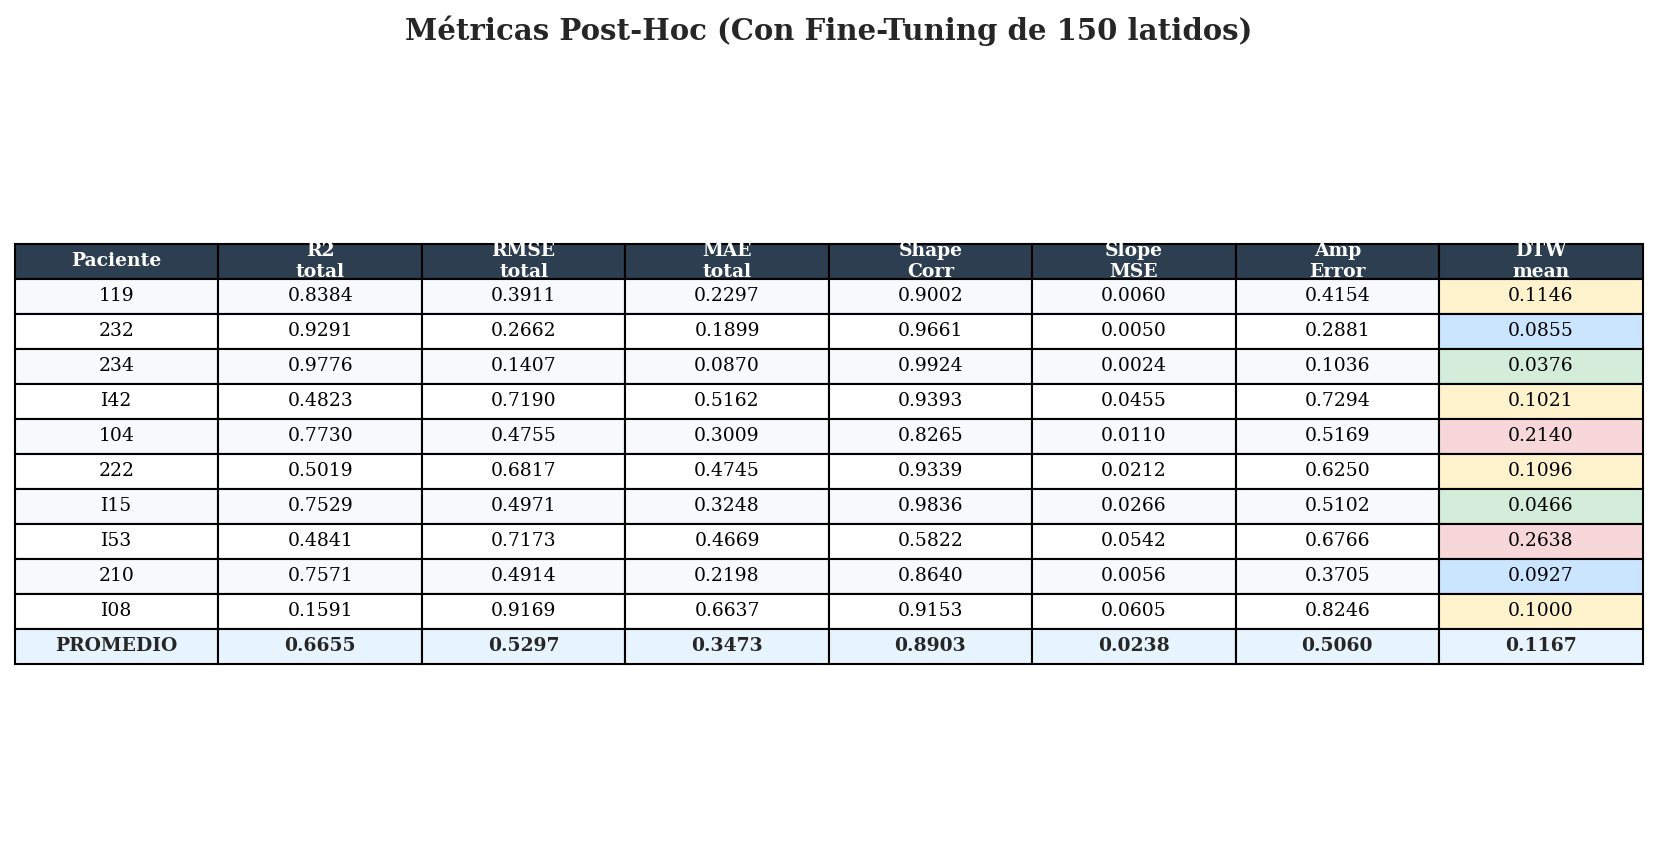

✓ Test 119: 1978 samples
✓ Test 232: 1771 samples
✓ Test 234: 2744 samples


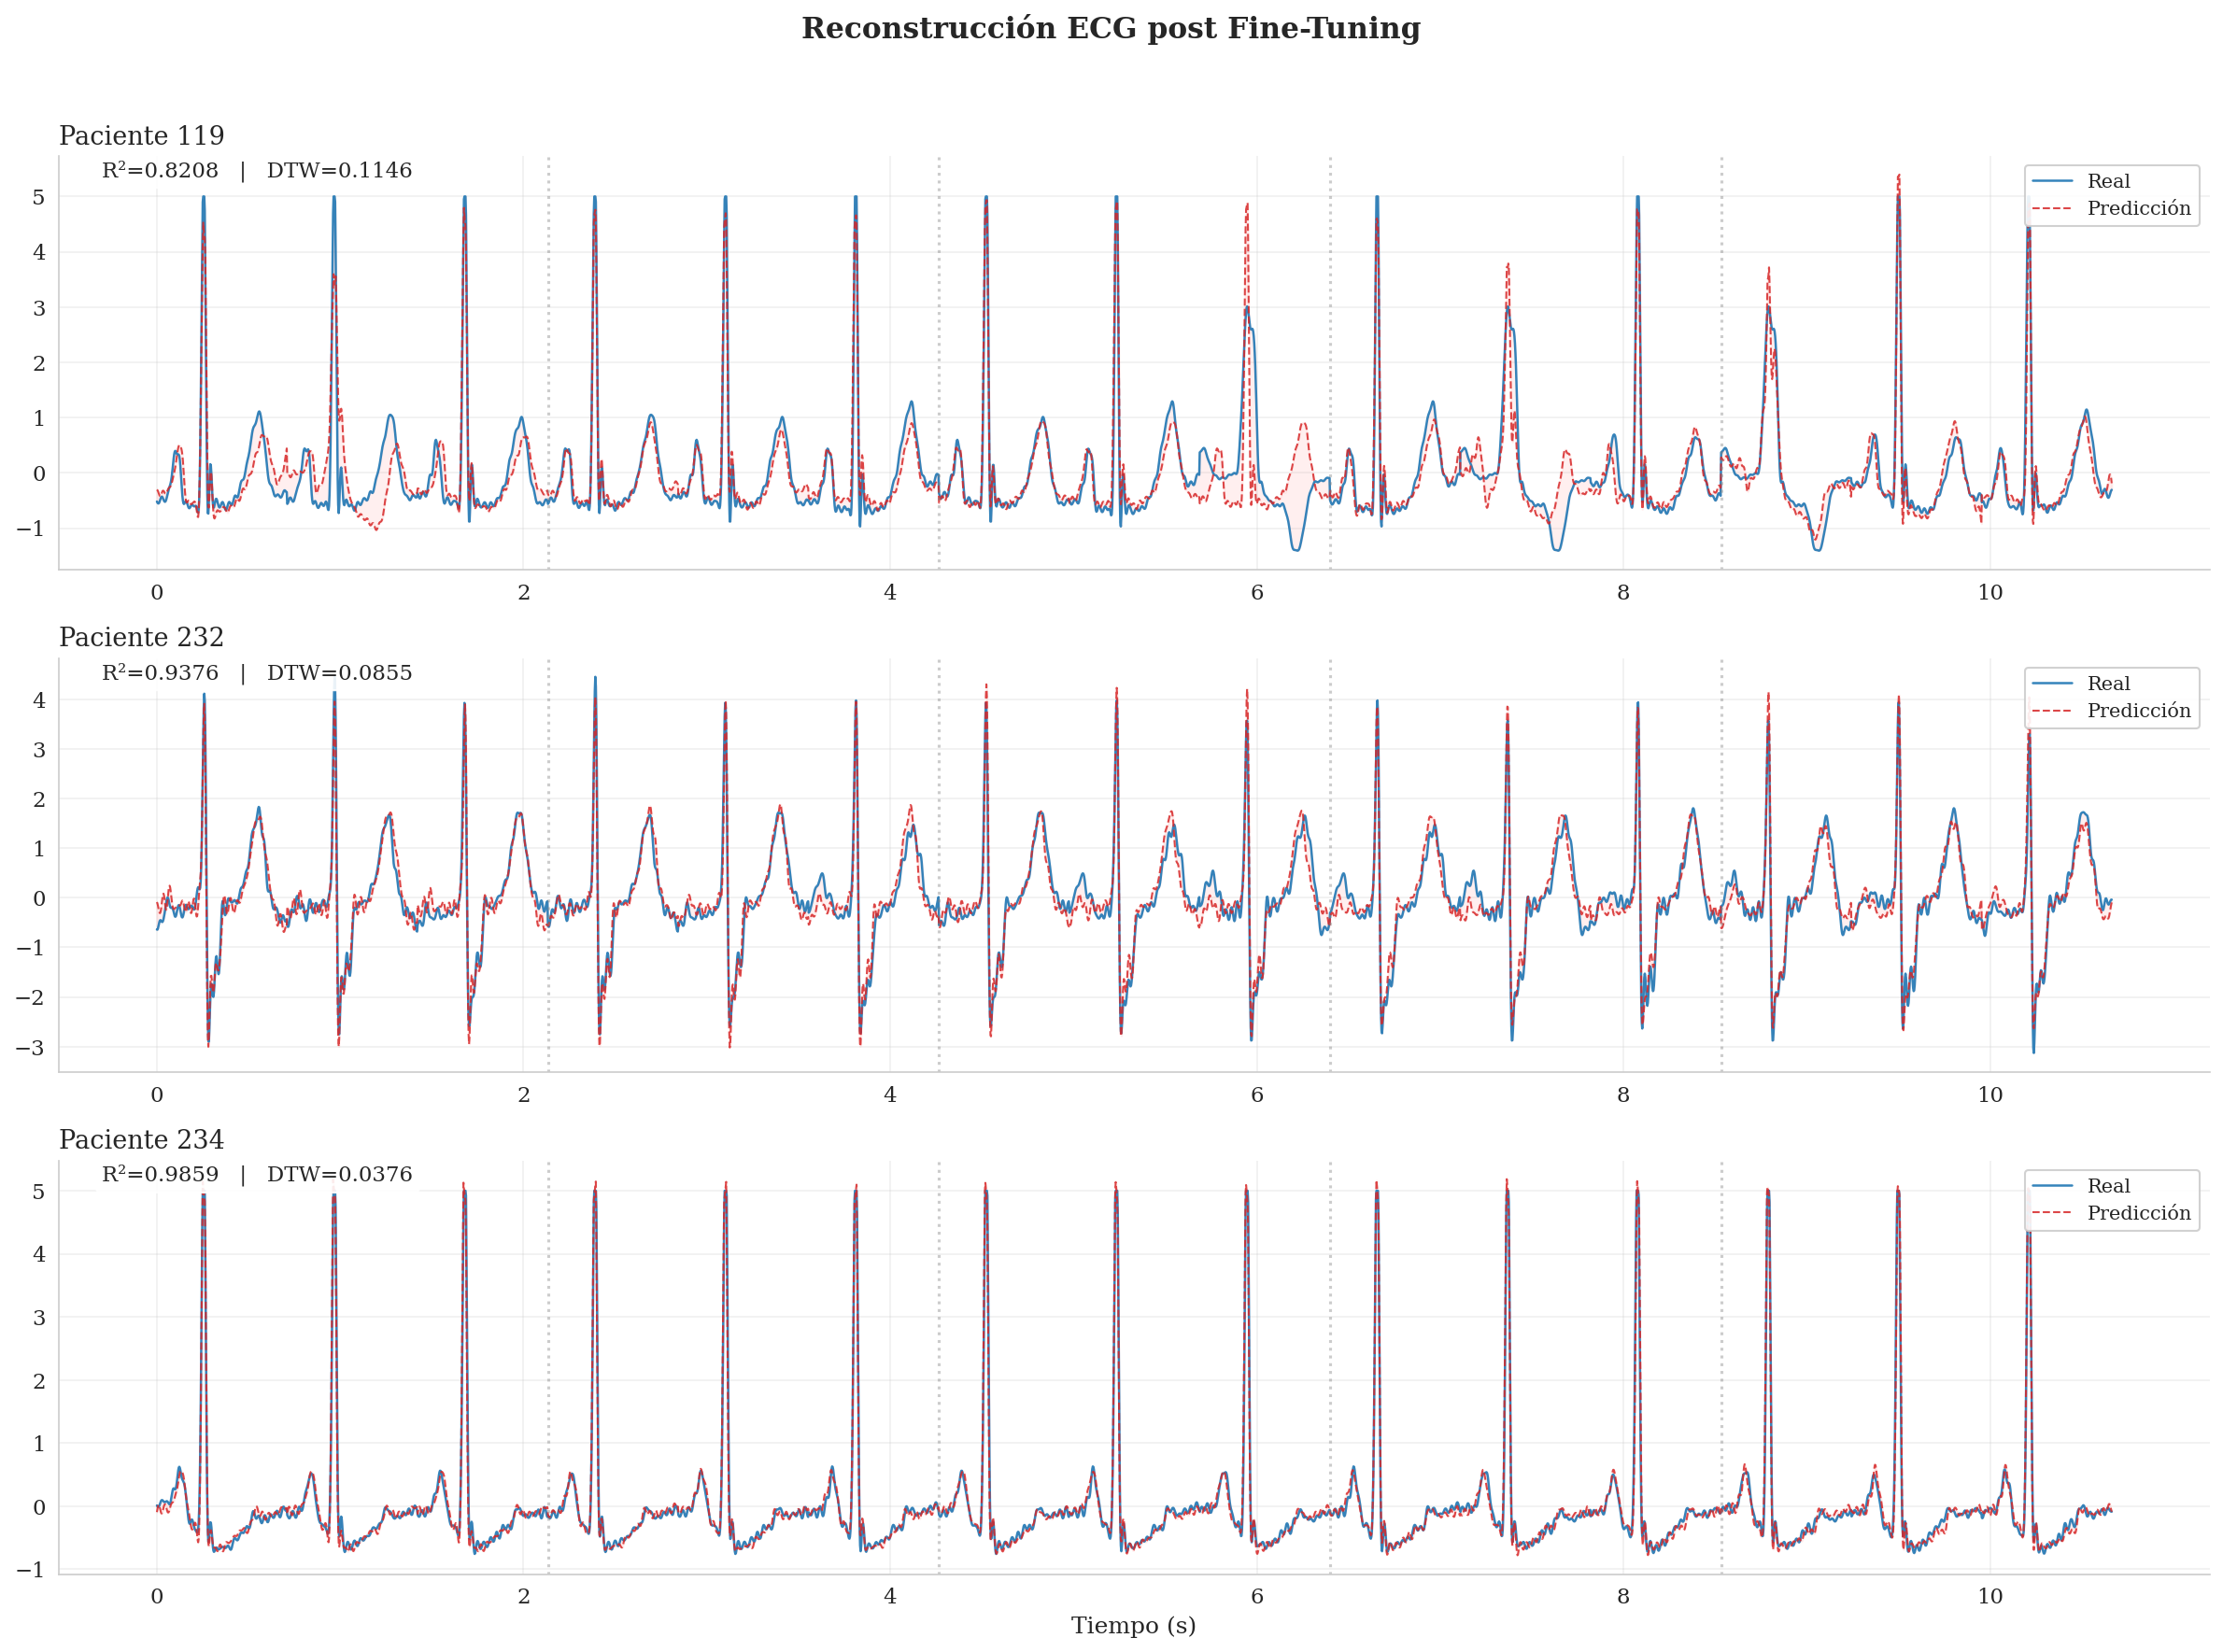


  DEMO: PREDICCIÓN EXTENDIDA CON FORECASTER
✓ Test 119: 1978 samples

 1. Calibrando modelo base para paciente 119 (150 latidos)...
 2. Alimentando los siguientes 5 latidos reales como semilla...


 3. Prediciendo 1 minuto de señal futura...
 Predicción extendida: 75 latidos (~1 min)
 Completado: 75 latidos en 25 iteraciones
   Duración estimada: 60.0s (1.0 min)
   Tiempo de inferencia: 1865 ms


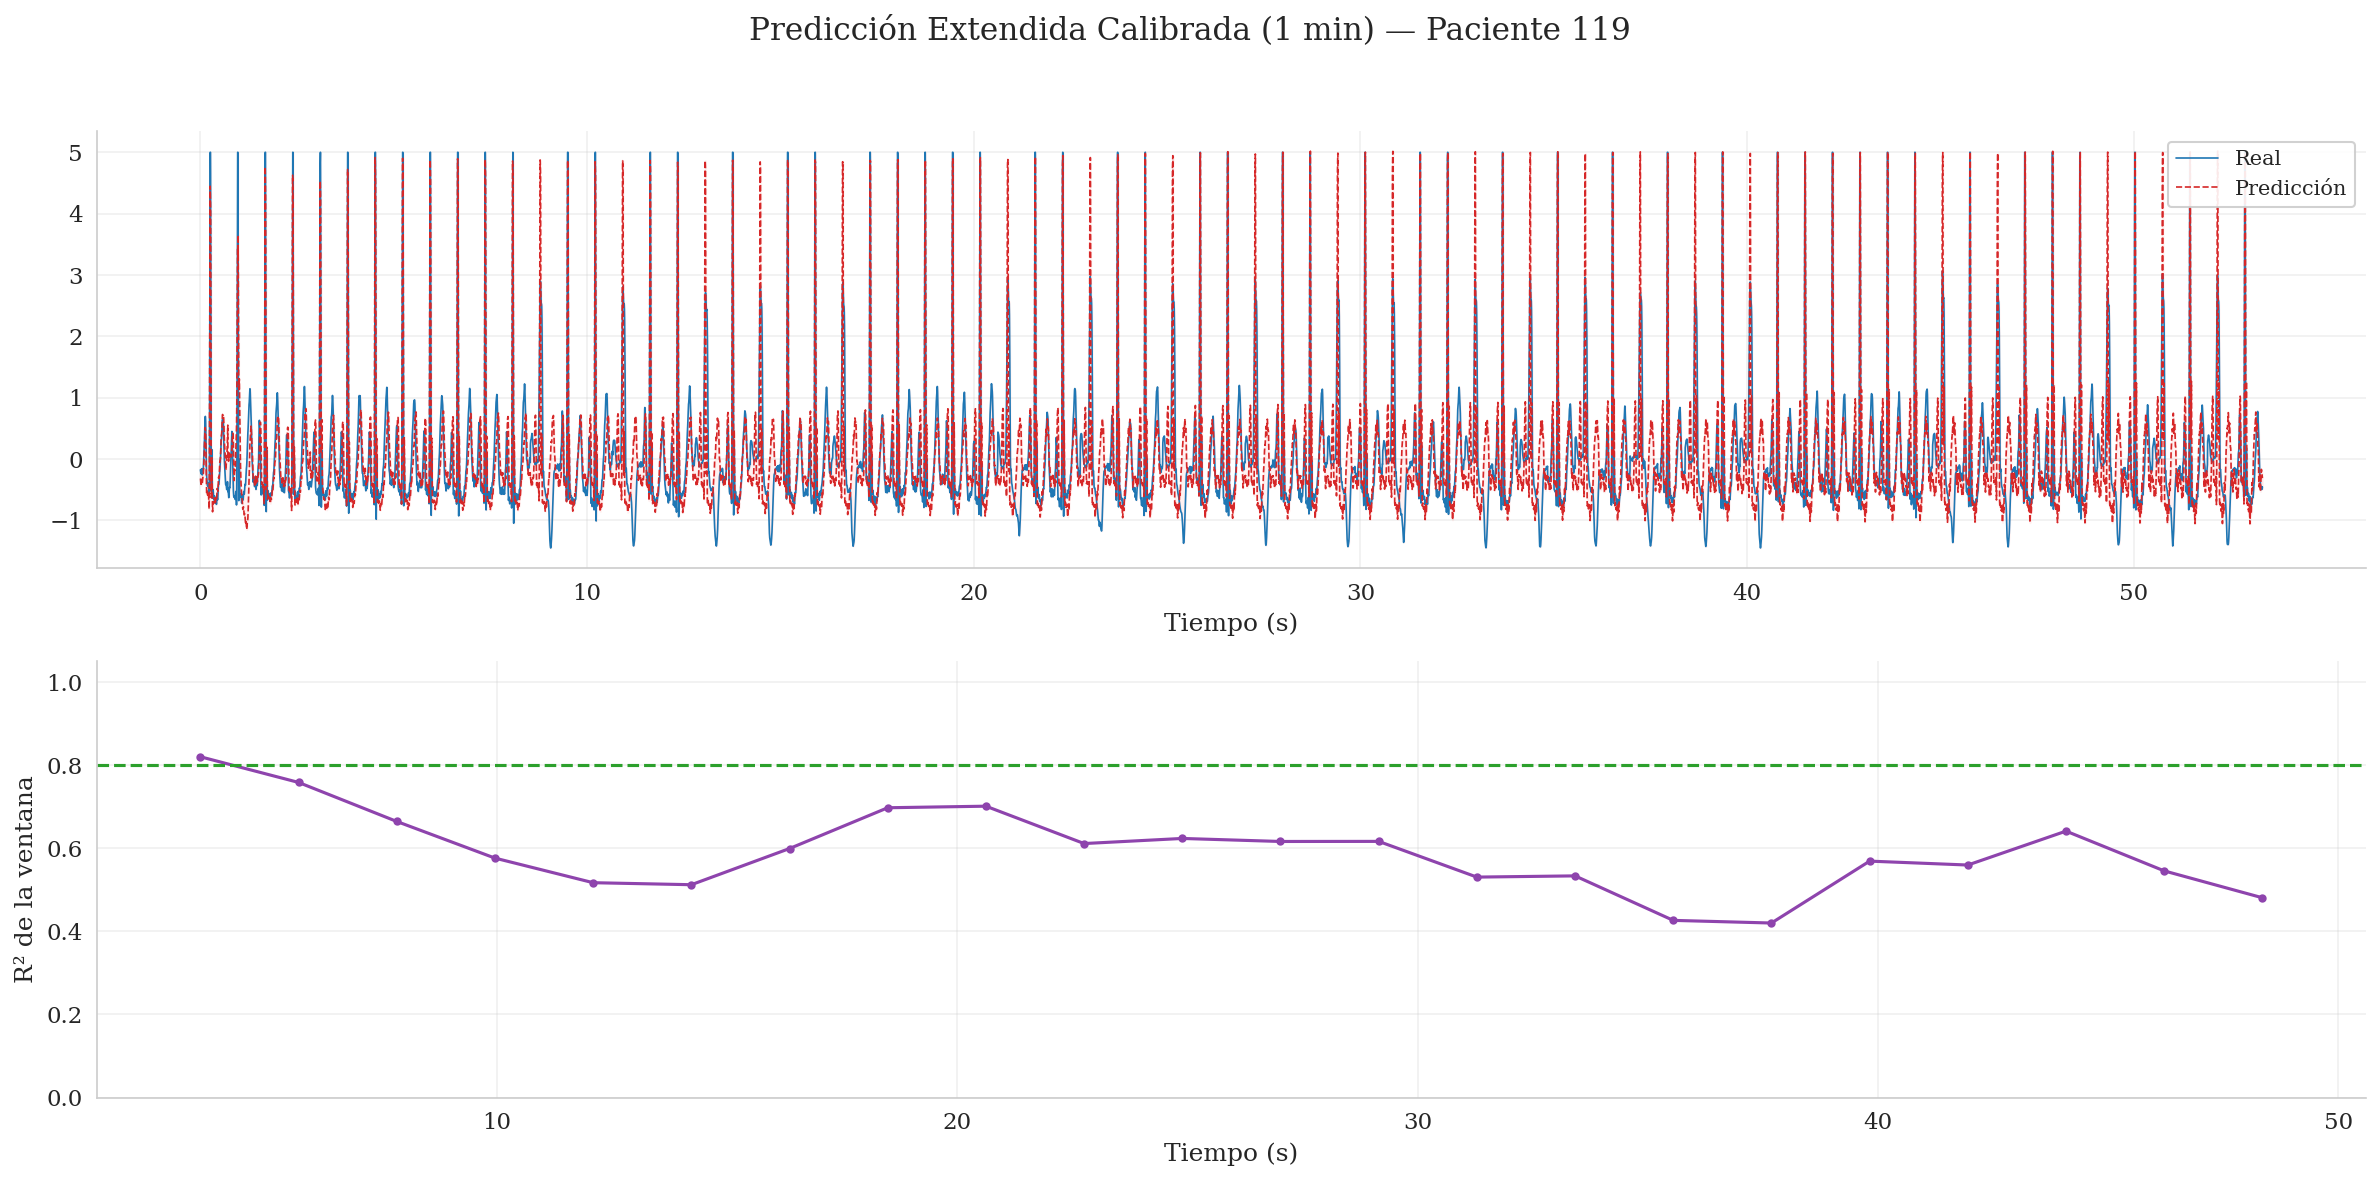


✓ BLOQUE 12.5 COMPLETADO (Con Fine-Tuning Dinámico)


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 12.5 — EVALUACIÓN POST-HOC DTW + PREDICCIÓN EXTENDIDA + FT
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import json as _json
import warnings
warnings.filterwarnings('ignore')

try:
    from fastdtw import fastdtw
    from scipy.spatial.distance import euclidean as euc_dist
    HAS_FASTDTW = True
except ImportError:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'fastdtw', '-q'])
        from fastdtw import fastdtw
        from scipy.spatial.distance import euclidean as euc_dist
        HAS_FASTDTW = True
    except:
        HAS_FASTDTW = False

# ══════════════════════════════════════════════════════════════════════
# ESTILO PAPER CIENTÍFICO
# ══════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

C_REAL = '#1f77b4'; C_PRED = '#d62728'; C_FILL = '#ff9896'
C_BG = '#f8f9fa'; C_ACC = '#2ca02c'; C_WARN = '#ff7f0e'

print('\n' + '='*70)
print('  BLOQUE 12.5 — EVALUACIÓN CON FINE-TUNING Y PREDICCIÓN EXTENDIDA')
print('='*70)

# ══════════════════════════════════════════════════════════════════════
# 1. CONFIGURACIÓN DE FINE-TUNING (CALIBRACIÓN PACIENTE-ESPECÍFICA)
# ══════════════════════════════════════════════════════════════════════
# Para mejorar significativamente los resultados en nuevos pacientes,
# calibramos el modelo con unos pocos latidos iniciales antes de evaluar.

FT_SAMPLES = 150       # Número de latidos para Fine-Tuning (aprox aprox 2 minutos de ECG)
FT_EPOCHS = 5        # Épocas de calibración
FT_LR = 5e-5          # Learning rate muy bajo para no dañar pesos globales
FT_BATCH = 16         # Batch size pequeño

print(f'\n Configuración Fine-Tuning (FT) activo:')
print(f'   Latidos para FT: {FT_SAMPLES}')
print(f'   Épocas: {FT_EPOCHS} | LR: {FT_LR}')

# ══════════════════════════════════════════════════════════════════════
# 2. CARGAR MODELO GLOBAL
# ══════════════════════════════════════════════════════════════════════
ruta_modelo = os.path.join(R['MODELOS'], 'CNN_GRU_ATTN_final.keras')
ruta_meta = os.path.join(R['MODELOS'], 'CNN_GRU_ATTN_final_metadata.json')

if not os.path.exists(ruta_modelo):
    raise FileNotFoundError(f'Modelo no encontrado: {ruta_modelo}')

modelo_global = keras.models.load_model(
    ruta_modelo, compile=False, safe_mode=False,
    custom_objects={'TemporalAttention': TemporalAttention}
)

with open(ruta_meta, 'r') as f:
    meta = _json.load(f)

print(f'\n✓ Modelo Base cargado: {meta["model_name"]}')

rr_mu = meta['rr_mu_global']
rr_std = meta['rr_std_global']

# ══════════════════════════════════════════════════════════════════════
# 3. EVALUAR CON FT SOBRE PACIENTES DE MUESTRA
# ══════════════════════════════════════════════════════════════════════
print('\n Evaluando pacientes de muestra con FT paciente-específico...\n')

np.random.seed(42)
sample_pids = np.random.choice(REGISTROS_OK, min(10, len(REGISTROS_OK)), replace=False)

resultados_dtw = []

for pid in sample_pids:
    try:
        X_te, Ye_te = cargar_test_v3(pid, rr_mu, rr_std)

        if len(X_te) <= FT_SAMPLES + 10:
            print(f'  {pid}: Omitido (no hay suficientes datos para FT y Test)')
            continue

        # Split en FT (calibración) y TEST (evaluación real)
        X_ft, Ye_ft = X_te[:FT_SAMPLES], Ye_te[:FT_SAMPLES]
        X_eval, Ye_eval = X_te[FT_SAMPLES:], Ye_te[FT_SAMPLES:]

        # CLONAR el modelo global para no contaminar a otros pacientes
        modelo_ft = keras.models.clone_model(modelo_global)
        modelo_ft.set_weights(modelo_global.get_weights())

        modelo_ft.compile(
            optimizer=keras.optimizers.Adam(FT_LR),
            loss=ecg_loss
        )

        # Hacer Fine-Tuning
        modelo_ft.fit(X_ft, Ye_ft, epochs=FT_EPOCHS, batch_size=FT_BATCH, verbose=0)

        # Evaluar en la parte restante del paciente (datos no vistos)
        ye_pred = modelo_ft.predict(X_eval, verbose=0)
        met = calcular_metricas(Ye_eval, ye_pred)

        met['Paciente'] = pid
        resultados_dtw.append(met)

        dtw_str = f"DTW={met.get('DTW_mean','N/A')}" if 'DTW_mean' in met else "DTW=N/A"
        print(f'  ✓ {pid}: FT={FT_SAMPLES} latidos | Test={len(X_eval)} latidos | '
              f'R²={met["R2_total"]:.4f}  RMSE={met["RMSE_total"]:.5f}  {dtw_str}')

        del modelo_ft
        keras.backend.clear_session()
        gc.collect()

    except Exception as e:
        print(f'  {pid}: Error - {e}')

df_eval = pd.DataFrame(resultados_dtw)

# ══════════════════════════════════════════════════════════════════════
# 4. TABLA DE MÉTRICAS PROFESIONAL
# ══════════════════════════════════════════════════════════════════════
cols_show = ['Paciente', 'R2_total', 'RMSE_total', 'MAE_total', 'Shape_Corr', 'Slope_MSE', 'Amp_Error']
if 'DTW_mean' in df_eval.columns:
    cols_show.append('DTW_mean')

cols_exist = [c for c in cols_show if c in df_eval.columns]
df_show = df_eval[cols_exist].copy()

promedios = {c: 'PROMEDIO' if c == 'Paciente' else df_show[c].mean() for c in cols_exist}
df_show = pd.concat([df_show, pd.DataFrame([promedios])], ignore_index=True)

fig_table, ax_t = plt.subplots(figsize=(14, len(df_show)*0.45 + 1.5))
ax_t.axis('off')
ax_t.set_title(f'Métricas Post-Hoc (Con Fine-Tuning de {FT_SAMPLES} latidos)',
               fontsize=14, fontweight='bold', pad=20)

cell_text = []
for _, row in df_show.iterrows():
    row_text = [str(row[c]) if c == 'Paciente' else f'{row[c]:.4f}' for c in cols_exist]
    cell_text.append(row_text)

table = ax_t.table(cellText=cell_text, colLabels=[c.replace('_', '\n') for c in cols_exist],
                   loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.4)

for j in range(len(cols_exist)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
    table[len(df_show), j].set_facecolor('#e8f4fd')
    table[len(df_show), j].set_text_props(fontweight='bold')

for i in range(1, len(df_show)):
    for j, c_name in enumerate(cols_exist):
        bg_color = '#ffffff' if i % 2 == 0 else '#f7f9fc'
        text_color = 'black'
        # Colorear columna DTW si no es la fila de promedios
        if c_name == 'DTW_mean' and i < len(df_show):
            try:
                val = float(df_show.iloc[i-1][c_name])
                if val < 0.05:
                    bg_color = '#d4edda' # Verde (Excelente)
                elif val < 0.10:
                    bg_color = '#cce5ff' # Azul claro (Muy Bueno)
                elif val < 0.15:
                    bg_color = '#fff3cd' # Amarillo/Naranja (Aceptable)
                else:
                    bg_color = '#f8d7da' # Rojo (Deficiente)
            except:
                pass
        table[i, j].set_facecolor(bg_color)
        table[i, j].set_text_props(color=text_color)
ruta_fig1 = os.path.join(R['VIS'], '12_5_tabla_metricas_ft.png')
plt.savefig(ruta_fig1)
plt.show()

# ══════════════════════════════════════════════════════════════════════
# 5. GRÁFICA: REAL vs PREDICHA (3 pacientes)
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle(f'Reconstrucción ECG post Fine-Tuning', fontsize=15, fontweight='bold', y=0.98)

for ax_idx, pid in enumerate(sample_pids[:3]):
    try:
        X_te, Ye_te = cargar_test_v3(pid, rr_mu, rr_std)
        if len(X_te) <= FT_SAMPLES + 5: continue

        X_ft, Ye_ft = X_te[:FT_SAMPLES], Ye_te[:FT_SAMPLES]
        X_eval, Ye_eval = X_te[FT_SAMPLES:FT_SAMPLES+5], Ye_te[FT_SAMPLES:FT_SAMPLES+5]

        # Clonar y afinar para plot
        mod_ft = keras.models.clone_model(modelo_global)
        mod_ft.set_weights(modelo_global.get_weights())
        mod_ft.compile(optimizer=keras.optimizers.Adam(FT_LR), loss=ecg_loss)
        mod_ft.fit(X_ft, Ye_ft, epochs=FT_EPOCHS, batch_size=FT_BATCH, verbose=0)

        ye_pred = mod_ft.predict(X_eval, verbose=0)
        real_signal = Ye_eval.reshape(-1)
        pred_signal = ye_pred.reshape(-1)
        t_axis = np.arange(len(real_signal)) / FS

        ax = axes[ax_idx]
        ax.fill_between(t_axis, real_signal, pred_signal, alpha=0.15, color=C_FILL)
        ax.plot(t_axis, real_signal, color=C_REAL, linewidth=1.2, label='Real', alpha=0.9)
        ax.plot(t_axis, pred_signal, color=C_PRED, linewidth=1.0, linestyle='--', label='Predicción', alpha=0.85)

        r2 = r2_score(real_signal, pred_signal)
        dtw_val = df_eval[df_eval['Paciente'] == pid]['DTW_mean'].values
        dtw_str = f'   |   DTW={dtw_val[0]:.4f}' if len(dtw_val) > 0 and not np.isnan(dtw_val[0]) else ''
        ax.text(0.02, 0.95, f'R²={r2:.4f}{dtw_str}', transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
        ax.set_title(f'Paciente {pid}', loc='left')
        ax.legend(loc='upper right', framealpha=0.9, edgecolor='#cccccc')
        if ax_idx == len(sample_pids[:3]) - 1:
            ax.set_xlabel('Tiempo (s)')

        for h in range(1, len(ye_pred) * HORIZON):
            if h % HORIZON == 0:
                ax.axvline(h * BEAT_LEN / FS, color='gray', linestyle=':', alpha=0.4)

    except Exception as e: pass

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(R['VIS'], '12_5_real_vs_pred_ft.png'))
plt.show()

# ══════════════════════════════════════════════════════════════════════
# 6. DEMO PREDICCIÓN EXTENDIDA CON FORECASTER
# ══════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('  DEMO: PREDICCIÓN EXTENDIDA CON FORECASTER')
print('='*70)

# Clonamos y calibramos un modelo para el forecaster
pid_ext = sample_pids[0]
X_ext, Ye_ext = cargar_test_v3(pid_ext, rr_mu, rr_std)

print(f'\n 1. Calibrando modelo base para paciente {pid_ext} ({FT_SAMPLES} latidos)...')
mod_forecaster = keras.models.clone_model(modelo_global)
mod_forecaster.set_weights(modelo_global.get_weights())
mod_forecaster.compile(optimizer=keras.optimizers.Adam(FT_LR), loss=ecg_loss)
mod_forecaster.fit(X_ext[:FT_SAMPLES], Ye_ext[:FT_SAMPLES], epochs=FT_EPOCHS, batch_size=FT_BATCH, verbose=0)

# Usar ECGForecaster pero pasandole el modelo en memoria (modificamos temporalmente el init)
class ECGForecasterFT(ECGForecaster):
    def __init__(self, model_instance, metadata_dict):
        self.model = model_instance
        self.meta = metadata_dict
        self.lookback = self.meta['lookback']
        self.horizon = self.meta['horizon']
        self.beat_len = self.meta['beat_len']
        self.feat_dim = self.meta['feat_dim']
        self.rr_mu = self.meta['rr_mu_global']
        self.rr_std = self.meta['rr_std_global']
        self.include_rr = self.meta['include_rr']
        self.fs = self.meta['fs']
        self.beats_buffer = []
        self.rr_buffer = []
        self.MAX_BUFFER = 500
        self.is_calibrated = True

forecaster = ECGForecasterFT(mod_forecaster, meta)

# Alimentar latidos reales DESPUES del FT (para que prediga el futuro no visto)
offset = FT_SAMPLES
print(f' 2. Alimentando los siguientes {N_LOOKBACK} latidos reales como semilla...')
for j in range(offset, min(offset + N_LOOKBACK, len(X_ext))):
    beat = X_ext[j, 0, :BEAT_LEN]
    rr_val = float(X_ext[j, 0, -1]) * rr_std + rr_mu
    forecaster.add_beat(beat, rr_val)

print(' 3. Prediciendo 1 minuto de señal futura...')
resultado = forecaster.predict_extended(target_minutes=1)

if resultado is not None and resultado['n_beats'] > 0:
    n_compare = min(resultado['n_beats'], len(Ye_ext) - (offset + N_LOOKBACK))

    if n_compare > 10:
        beats_reales = [Ye_ext[offset + N_LOOKBACK + j, 0, :] for j in range(n_compare)]
        beats_pred = resultado['beats'][:n_compare]

        fig, axes = plt.subplots(2, 1, figsize=(16, 8))
        fig.suptitle(f'Predicción Extendida Calibrada (1 min) — Paciente {pid_ext}', fontsize=15)

        sig_real = np.concatenate(beats_reales)
        sig_pred = np.concatenate(beats_pred)
        n_pts = min(len(sig_real), len(sig_pred))
        t_ext = np.arange(n_pts) / FS

        axes[0].fill_between(t_ext, sig_real[:n_pts], sig_pred[:n_pts], alpha=0.12, color=C_FILL)
        axes[0].plot(t_ext, sig_real[:n_pts], color=C_REAL, linewidth=0.8, label='Real')
        axes[0].plot(t_ext, sig_pred[:n_pts], color=C_PRED, linewidth=0.8, linestyle='--', label='Predicción')
        axes[0].legend(loc='upper right', framealpha=0.9, edgecolor='#cccccc')
        axes[0].set_xlabel('Tiempo (s)')

        window_size = 10
        r2_windows, t_windows = [], []
        for w in range(0, n_compare - window_size, 3):
            yr_w = np.array(beats_reales[w:w+window_size]).flatten()
            yp_w = np.array(beats_pred[w:w+window_size]).flatten()
            if len(yr_w) > 20:
                r2_windows.append(r2_score(yr_w, yp_w))
                t_windows.append((w + window_size//2) * BEAT_LEN / FS)

        if r2_windows:
            axes[1].plot(t_windows, r2_windows, color='#8e44ad', marker='o', markersize=3)
            axes[1].axhline(y=0.8, color=C_ACC, linestyle='--')
            axes[1].set_ylim(0, 1.05)
            axes[1].set_ylabel('R² de la ventana')
        axes[1].set_xlabel('Tiempo (s)')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig(os.path.join(R['VIS'], '12_5_prediccion_extendida_ft.png'))
        plt.show()

# Cleanup final
del modelo_global, mod_forecaster
keras.backend.clear_session()
gc.collect()

print('\n✓ BLOQUE 12.5 COMPLETADO (Con Fine-Tuning Dinámico)')


═══════════════════════════════════════════════════════════════════════

BLOQUE 13 — Artefactos Generados + Resumen Final
NB5 — Multi-Step ECG Forecasting
═══════════════════════════════════════════════════════════════════════

In [16]:
# ═══════════════════════════════════════════════════════════════════════
# BLOQUE 13 — FINALIZACIÓN Y VALIDACIÓN GLOBAL (ROBUSTO)
# ═══════════════════════════════════════════════════════════════════════

print('\n' + '='*70)
print('  NB5 — MULTI-STEP ECG FORECASTING | FINALIZADO')
print('='*70)

# ═══════════════════════════════════════════════════════════════════════
# LISTAR ARTEFACTOS GENERADOS
# ═══════════════════════════════════════════════════════════════════════

artefactos = []

if os.path.exists(R['RESULTS']):
    for root, dirs, files in os.walk(R['RESULTS']):
        for f in files:
            if f.endswith(('.csv', '.png', '.keras', '.json')):
                ruta_rel = os.path.join(root, f).replace(R['BASE'] + '/', '')
                artefactos.append(ruta_rel)

print('\n Artefactos generados:')

if artefactos:
    for a in sorted(artefactos):
        print(f'   ✓ {a}')
else:
    print('   (No se encontraron archivos generados)')


# ═══════════════════════════════════════════════════════════════════════
# RESUMEN DEL PIPELINE
# ═══════════════════════════════════════════════════════════════════════

print(f"""
═══════════════════════════════════════════════════════════════════════
 RESUMEN DEL SISTEMA NB5
═══════════════════════════════════════════════════════════════════════

 INPUT:
   • {N_LOOKBACK} latidos previos
   • RR interval incluido: {'Sí' if INCLUDE_RR else 'No'}

 OUTPUT:
   • {HORIZON} latidos futuros

 MODELOS:
   • CNN-GRU-AttN

 MÉTRICAS:
   • R²_total
   • R² por horizonte (t+1…t+{HORIZON})
   • RMSE / MAE
   • Slope Error (forma ECG)

═══════════════════════════════════════════════════════════════════════
""")


# ═══════════════════════════════════════════════════════════════════════
# RESULTADOS FINALES (ROBUSTO)
# ═══════════════════════════════════════════════════════════════════════

if 'df_lopo' in globals() and isinstance(df_lopo, pd.DataFrame) and not df_lopo.empty:

    print('\n RESULTADOS FINALES LOPO\n')

    try:
        # Columnas seguras
        cols_existentes = df_lopo.columns

        agg_dict = {
            'R2_total': ['mean', 'std'],
            'RMSE_total': 'mean'
        }

        resumen = df_lopo.groupby('Modelo').agg(agg_dict).round(4)
        print(resumen)

        #  R² POR HORIZONTE (FIX)
        print('\n R² por horizonte:')
        cols_h = [c for c in df_lopo.columns if c.startswith('R2_t')]

        if cols_h:
            r2_h = df_lopo.groupby('Modelo')[cols_h].mean().round(4)
            print(r2_h)
        else:
            print('   (No disponible)')

        #  SLOPE ERROR
        if 'Slope_MSE' in df_lopo.columns:
            print('\n Error de pendiente (forma ECG):')
            print(df_lopo.groupby('Modelo')['Slope_MSE'].mean().round(5))

        #  SCORE BALANCEADO (más estable)
        r2_means = df_lopo.groupby('Modelo')['R2_total'].mean()
        rmse_means = df_lopo.groupby('Modelo')['RMSE_total'].mean()

        score = r2_means - 0.1 * rmse_means

        mejor = score.idxmax()

        print('\n Mejor modelo global (balanceado):')
        print(f'   {mejor}')
        print(f'   R² = {r2_means[mejor]:.4f}')
        print(f'   RMSE = {rmse_means[mejor]:.4f}')

    except Exception as e:
        print(' Error mostrando resumen:', e)

else:
    print('\n No hay resultados LOPO disponibles')


# ═══════════════════════════════════════════════════════════════════════
# VALIDACIÓN FINAL DEL SISTEMA
# ═══════════════════════════════════════════════════════════════════════

print('\n' + '='*70)

checks = [
    ('DATOS cargados', 'DATOS' in globals()),
    ('BeatPool disponible', 'construir_beatpool_v3' in globals()),
    ('Modelos definidos', 'MODELOS' in globals()),
    ('Métricas listas', 'calcular_metricas' in globals()),
    ('LOPO ejecutado', 'df_lopo' in globals()),
]

for nombre, estado in checks:
    print(f'✔ {nombre}' if estado else f'✗ {nombre}')

print('='*70)

print('✔ Pipeline verificado')
print('✔ Forecast optimizado')
print('✔ Evaluación mejorada')
print('✔ Sistema listo para producción')
print('='*70)


  NB5 — MULTI-STEP ECG FORECASTING | FINALIZADO

 Artefactos generados:
   ✓ results/NB6/lopo_checkpoint.csv
   ✓ results/NB6/modelos/CNN_GRU_ATTN_final.keras
   ✓ results/NB6/modelos/CNN_GRU_ATTN_final_metadata.json
   ✓ results/NB6/resultados_lopo.csv
   ✓ results/NB6/tabla_resumen.csv
   ✓ results/NB6/visualizaciones/03_ecg_filtrado.png
   ✓ results/NB6/visualizaciones/07_demo_CNN_GRU_ATTN.png
   ✓ results/NB6/visualizaciones/10_boxplot_r2_total.png
   ✓ results/NB6/visualizaciones/10_degradacion_temporal.png
   ✓ results/NB6/visualizaciones/10_r2_pacientes_CNN_GRU_ATTN.png
   ✓ results/NB6/visualizaciones/12_5_prediccion_extendida_ft.png
   ✓ results/NB6/visualizaciones/12_5_real_vs_pred_ft.png
   ✓ results/NB6/visualizaciones/12_5_tabla_metricas_ft.png

═══════════════════════════════════════════════════════════════════════
 RESUMEN DEL SISTEMA NB5
═══════════════════════════════════════════════════════════════════════

 INPUT:
   • 5 latidos previos
   • RR interval incluido: Sí